In [1]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Dec 11 00:22:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:0A:00.0  On |                  N/A |
|  0%   35C    P8             19W /  370W |    2226MiB /  10240MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# !pip install boruta
# !pip install smote_variants
# !pip install lime
# !pip install signaturizer

In [4]:
#import default and other essential libraries
import os
import numpy as np
import pandas as pd
import sklearn
import joblib
import pickle
import csv
import sys
import random
import seaborn as sns
from functools import reduce
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt
import tensorflow as tf

In [5]:
#Packages to split data and other preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.decomposition import PCA
from boruta import BorutaPy
from imblearn.pipeline import Pipeline as sample_pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [6]:
#Import Classifiers
from sklearn import svm
import smote_variants as sv
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
## Package for calculating accuracy and analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score, cohen_kappa_score, f1_score, precision_score, recall_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from lime.lime_tabular import LimeTabularExplainer

In [8]:
from signaturizer import Signaturizer
from tqdm import tqdm

In [9]:
def handle_missing_values(data):
    print('Handling missing values')
    data = data.replace([np.inf, -np.inf, "", " "], np.nan)
    data = data.replace(["", " "], np.nan)
    for i in data.columns:
        data[i] = data[i].fillna(data[i].mean())
    return data

def Feature_Signaturizer(dat):
    sig_df=pd.DataFrame()
    desc=['A','B','C','D','E']
    for dsc in tqdm(desc):
        for i in range(1,6):
            sign = Signaturizer(dsc+str(i), local=True)
            results = sign.predict(dat)
            df=pd.DataFrame(results.signature)
            for clm in list(df.columns):
                df=df.rename(columns={clm:dsc+str(i)+'_'+str(clm)})
            sig_df=pd.concat([sig_df,df],axis = 1)
    sig_df = handle_missing_values(sig_df)
    res = pd.DataFrame()
    res['smiles'] = dat
    res = pd.concat([res,sig_df],axis = 1)
    return res

In [10]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'AID_1259408_datatable_all.csv') ### features in columns,molecules in rows
# 1. 根据列名为 PUBCHEM_CID 的取值去除重复的
data = data.drop_duplicates(subset='PUBCHEM_CID')

# 2. 替换 PUBCHEM_ACTIVITY_OUTCOME 列的取值
data['PUBCHEM_ACTIVITY_OUTCOME'] = data['PUBCHEM_ACTIVITY_OUTCOME'].replace({
    'Active': 1,
    'Inactive': 0,
    'Unspecified': np.nan
})

# 将 'Status' 列名修改为 'status'
data = data.rename(columns={'PUBCHEM_ACTIVITY_OUTCOME': 'status'})

# 3. 删除 SMILES 和 PUBCHEM_ACTIVITY_OUTCOME 两列中任一有空值的行
data = data.dropna(subset=['SMILES', 'status'])

# 4. 重新设置索引
data.reset_index(drop=True, inplace=True)

# 输出处理后的数据
data

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,SMILES,status
0,7,363894742,148318.0,C1CN2CC=C([C@@H]2[C@@H]1OC(=O)C3=CC4=C(C=C3)OC...,1.0
1,29,363894749,4763.0,CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2,1.0
2,34,363894750,5746.0,CC1=C(C(=O)C2=C(C1=O)N3C[C@H]4[C@@H]([C@@]3([C...,1.0
3,74,363894751,2907.0,C1CNP(=O)(OC1)N(CCCl)CCCl,1.0
4,117,363894752,5755.0,C[C@]12C[C@@H]([C@H]3[C@H]([C@@H]1CC[C@@]2(C(=...,1.0
...,...,...,...,...,...
2264,8570,363897941,119489.0,CN1C=CC(=C1CO)CO,1.0
2265,8574,363897945,47607.0,CS(=O)(=O)O.C1CN(CC2=CC(=NN=C21)NN)C(=O)C3=CC=...,1.0
2266,8575,363897946,149434.0,CN1C=CC(=C1)CO,1.0
2267,8580,363897949,25559.0,C(=O)([O-])[O-].O.O.O.O.[Ni].[Ni].[Ni+2],1.0


In [11]:
# 提取 SMILES 列
data_smiles = data['SMILES']
# 使用 Feature_Signaturizer 计算特征
data_features = Feature_Signaturizer(data_smiles)

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]
Parsing SMILES: 0it [00:00, ?it/s]
Parsing SMILES: 896it [00:00, 8957.94it/s]
Parsing SMILES: 2269it [00:00, 7586.92it/s]

Generating signatures:   0%|                                                                    | 0/18 [00:00<?, ?it/s]

1/1 [==============================] - 0s 51ms/step



Generating signatures:   6%|███▎                                                        | 1/18 [00:00<00:06,  2.45it/s]

1/1 [==============================] - 0s 22ms/step



Generating signatures:  11%|██████▋                                                     | 2/18 [00:00<00:05,  3.04it/s]

...

1/1 [==============================] - 0s 23ms/step



Generating signatures:  94%|███████████████████████████████████████████████████████▋   | 17/18 [00:04<00:00,  3.65it/s]

1/1 [==============================] - 0s 53ms/step



100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:44<00:00, 32.94s/it]


Handling missing values


In [12]:
# 保留原始的 'status' 列
data = pd.concat([data_features, data['status']], axis=1)
data.to_csv('data_1259408.csv')
# 打印查看结果
print(data)

                                                 smiles      A1_0      A1_1  \
0     C1CN2CC=C([C@@H]2[C@@H]1OC(=O)C3=CC4=C(C=C3)OC...  0.094017 -0.055076   
1                     CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2 -0.105077 -0.104956   
2     CC1=C(C(=O)C2=C(C1=O)N3C[C@H]4[C@@H]([C@@]3([C... -0.093861  0.104295   
3                             C1CNP(=O)(OC1)N(CCCl)CCCl -0.099617  0.087032   
4     C[C@]12C[C@@H]([C@H]3[C@H]([C@@H]1CC[C@@]2(C(=... -0.091825  0.092849   
...                                                 ...       ...       ...   
2264                                   CN1C=CC(=C1CO)CO  0.080106  0.102272   
2265  CS(=O)(=O)O.C1CN(CC2=CC(=NN=C21)NN)C(=O)C3=CC=... -0.104569  0.107861   
2266                                     CN1C=CC(=C1)CO  0.034375  0.083198   
2267           C(=O)([O-])[O-].O.O.O.O.[Ni].[Ni].[Ni+2] -0.095957  0.075977   
2268                    CC(C)NC(=O)C1=CC=C(C=C1)CNNC.Cl -0.097536  0.099165   

          A1_2      A1_3      A1_4      A1_5      A

In [13]:
# dropping ALL duplicate values, if any
data.drop_duplicates(subset ="smiles", keep = 'first', inplace = True, ignore_index = True)
data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,C1CN2CC=C([C@@H]2[C@@H]1OC(=O)C3=CC4=C(C=C3)OC...,0.094016,-0.055136,0.093916,0.094049,0.094048,0.094023,-0.094049,-0.093270,0.093939,...,-0.007912,-0.008366,-0.116818,-0.006744,0.023309,-0.086551,0.110998,-0.016755,0.126777,1.0
1,CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2,-0.105073,-0.104954,0.077949,-0.098966,0.051879,0.102551,-0.077809,0.094111,0.098754,...,-0.108469,-0.066381,0.049937,-0.007060,-0.099508,-0.064876,-0.117822,0.017419,0.065876,1.0
2,CC1=C(C(=O)C2=C(C1=O)N3C[C@H]4[C@@H]([C@@]3([C...,-0.093852,0.104293,0.104566,-0.105432,0.100401,-0.100579,-0.042242,0.105463,0.087505,...,0.003295,0.079961,0.068431,0.072388,0.031704,-0.156894,-0.076025,0.043912,0.091646,1.0
3,C1CNP(=O)(OC1)N(CCCl)CCCl,-0.099614,0.087038,0.060907,-0.098148,-0.045818,0.092176,0.090120,0.086224,-0.043515,...,-0.058454,-0.023720,0.095611,-0.074631,-0.109076,0.044256,-0.090629,-0.113879,-0.077791,1.0
4,C[C@]12C[C@@H]([C@H]3[C@H]([C@@H]1CC[C@@]2(C(=...,-0.091825,0.092849,0.092849,-0.092848,0.092849,-0.080430,0.092843,0.092849,-0.043309,...,0.105175,0.081506,0.056766,0.095901,0.101593,-0.104216,-0.058318,0.077261,-0.096527,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2264,CN1C=CC(=C1CO)CO,0.080092,0.102274,-0.009088,-0.057085,-0.101187,0.098601,0.106478,-0.105857,-0.106245,...,0.083240,-0.123522,0.145380,0.077607,-0.065158,-0.054499,0.016188,0.026602,0.055832,1.0
2265,CS(=O)(=O)O.C1CN(CC2=CC(=NN=C21)NN)C(=O)C3=CC=...,-0.104570,0.107860,0.071371,-0.107122,0.084389,0.097258,0.099946,-0.107713,-0.028845,...,-0.003408,0.045207,0.032738,0.038317,0.114978,0.135628,-0.058013,0.165188,0.000684,1.0
2266,CN1C=CC(=C1)CO,0.034437,0.083233,-0.097841,-0.074154,-0.099665,0.100696,0.101261,-0.100458,-0.100485,...,-0.003826,0.053155,0.184424,0.136455,-0.098094,-0.129598,-0.074668,0.090778,0.003947,1.0
2267,C(=O)([O-])[O-].O.O.O.O.[Ni].[Ni].[Ni+2],-0.095955,0.076007,0.092876,0.094680,0.094566,0.096064,0.095005,-0.096065,-0.092807,...,0.043008,-0.037532,0.102230,0.111853,-0.071334,-0.127195,0.113832,-0.002970,0.071206,1.0


In [14]:
def Boruta_Filteration(X_train,y_train,X_test,y_test):
    #### making files for boruta
    features = [f for f in X_train.columns if f not in ['status']]
    X_train_boruta = X_train[features].values
    Y_train_boruta = y_train.values.ravel()
    X_test_boruta = X_test[features].values
    Y_test_boruta = y_test.values.ravel()

    print('Before filteration\nTrain shape\n',X_train_boruta.shape,'\nTest shape\n',X_test_boruta.shape)

    ### implementing boruta

    # define random forest classifier, with utilising all cores and
    # sampling in proportion to y labels
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # define Boruta feature selection method
    feat_selector = BorutaPy(rf, n_estimators=100, random_state=1)

    # find all relevant features - 5 features should be selected
    feat_selector.fit(X_train_boruta, Y_train_boruta)

    # check selected features - first 5 features are selected
    feat_selector.support_

    # check ranking of features
    feat_selector.ranking_

    # call transform() on X to filter it down to selected features
    X_train_filtered = feat_selector.transform(X_train_boruta)
    X_test_filtered = feat_selector.transform(X_test_boruta)

    ### name of the features selected####
    final_features = list()
    indexes = np.where(feat_selector.support_ == True)
    for x in np.nditer(indexes):
        final_features.append(features[x])

    print('# of Features selected:',len(final_features))

    X_train_filtered=pd.DataFrame(X_train_filtered,columns=final_features)
    X_test_filtered=pd.DataFrame(X_test_filtered,columns=final_features)

    print('After filteration\nTrain shape\n',X_train_filtered.shape,'\nTest shape\n',X_test_filtered.shape)

    return X_train_filtered,X_test_filtered,Y_train_boruta,Y_test_boruta,final_features

In [15]:
'''
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        #plt.legend(loc="lower right")
        plt.show()
'''

'\ndef TSNE_plot(data,data_labels):\n        tsne = TSNE(n_components=2, random_state=50)\n        transformed_data = tsne.fit_transform(data)\n        k = np.array(transformed_data)\n        Group=["Class 0","Class 1"]\n        plt.scatter(k[:, 0],k[:, 1], c=data_labels)\n        #plt.legend(loc="lower right")\n        plt.show()\n'

In [16]:
'''
def Smote(traindata,trainlabel,prop):
        oversampler= sv.MSMOTE(proportion=prop,random_state=50)
        X_samp, y_samp= oversampler.sample(traindata.values,trainlabel.values)     
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()
'''

In [28]:
from imblearn.under_sampling import RandomUnderSampler
def Smote(traindata,trainlabel):
        # define undersample strategy
        undersample = RandomUnderSampler(sampling_strategy='majority')
        # fit and apply the transform
        X_samp, y_samp = undersample.fit_resample(traindata.values,trainlabel.values)        
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()

In [17]:
# Set random seed to maintain the randomness of each hyperparameter tuning run
def seed_all():
    np.random.seed(123)
    tf.random.set_seed(123)
seed_all()

In [18]:
# Make a new directory for HyperParameter Tuning
os.mkdir('AID_1259408')

In [19]:
# FROM = Path of directory from which to load the preprocessed signaturizer file
FROM='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao'
# TO = Path of the newly made HyperParameter Tuning directory
TO='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao/AID_1259408/'

# Set the HPTuning directory as the current working directory
os.chdir(TO)

In [20]:
Data=data.dropna()
Data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,C1CN2CC=C([C@@H]2[C@@H]1OC(=O)C3=CC4=C(C=C3)OC...,0.094016,-0.055136,0.093916,0.094049,0.094048,0.094023,-0.094049,-0.093270,0.093939,...,-0.007912,-0.008366,-0.116818,-0.006744,0.023309,-0.086551,0.110998,-0.016755,0.126777,1.0
1,CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2,-0.105073,-0.104954,0.077949,-0.098966,0.051879,0.102551,-0.077809,0.094111,0.098754,...,-0.108469,-0.066381,0.049937,-0.007060,-0.099508,-0.064876,-0.117822,0.017419,0.065876,1.0
2,CC1=C(C(=O)C2=C(C1=O)N3C[C@H]4[C@@H]([C@@]3([C...,-0.093852,0.104293,0.104566,-0.105432,0.100401,-0.100579,-0.042242,0.105463,0.087505,...,0.003295,0.079961,0.068431,0.072388,0.031704,-0.156894,-0.076025,0.043912,0.091646,1.0
3,C1CNP(=O)(OC1)N(CCCl)CCCl,-0.099614,0.087038,0.060907,-0.098148,-0.045818,0.092176,0.090120,0.086224,-0.043515,...,-0.058454,-0.023720,0.095611,-0.074631,-0.109076,0.044256,-0.090629,-0.113879,-0.077791,1.0
4,C[C@]12C[C@@H]([C@H]3[C@H]([C@@H]1CC[C@@]2(C(=...,-0.091825,0.092849,0.092849,-0.092848,0.092849,-0.080430,0.092843,0.092849,-0.043309,...,0.105175,0.081506,0.056766,0.095901,0.101593,-0.104216,-0.058318,0.077261,-0.096527,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2264,CN1C=CC(=C1CO)CO,0.080092,0.102274,-0.009088,-0.057085,-0.101187,0.098601,0.106478,-0.105857,-0.106245,...,0.083240,-0.123522,0.145380,0.077607,-0.065158,-0.054499,0.016188,0.026602,0.055832,1.0
2265,CS(=O)(=O)O.C1CN(CC2=CC(=NN=C21)NN)C(=O)C3=CC=...,-0.104570,0.107860,0.071371,-0.107122,0.084389,0.097258,0.099946,-0.107713,-0.028845,...,-0.003408,0.045207,0.032738,0.038317,0.114978,0.135628,-0.058013,0.165188,0.000684,1.0
2266,CN1C=CC(=C1)CO,0.034437,0.083233,-0.097841,-0.074154,-0.099665,0.100696,0.101261,-0.100458,-0.100485,...,-0.003826,0.053155,0.184424,0.136455,-0.098094,-0.129598,-0.074668,0.090778,0.003947,1.0
2267,C(=O)([O-])[O-].O.O.O.O.[Ni].[Ni].[Ni+2],-0.095955,0.076007,0.092876,0.094680,0.094566,0.096064,0.095005,-0.096065,-0.092807,...,0.043008,-0.037532,0.102230,0.111853,-0.071334,-0.127195,0.113832,-0.002970,0.071206,1.0


In [21]:
# Use 90% of the Data as Training Data for further hyperparameter tuning
Train=Data.sample(n=int(len(Data)*0.9), random_state=1)
Train

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
2108,COC1=CC=C(C=C1)C(=O)N2C3=CC=CC=C3CC4=CC=CC=C42,-0.046794,-0.096013,-0.083414,-0.101821,0.101324,-0.101383,0.050861,-0.011695,0.101805,...,-0.098584,0.080094,0.052880,0.080557,0.017694,-0.122507,-0.105437,0.114212,-0.021032,1.0
107,C1=CC=C2C(=C1)C=CC(=O)N2,0.098530,-0.069395,0.086933,-0.098480,-0.098585,-0.095451,0.098585,-0.097197,-0.098447,...,0.087571,-0.030280,0.009769,-0.042192,0.027119,-0.030987,0.040072,0.022811,-0.109747,0.0
1084,CCN(CC)C1=CC=C(C=C1)N=NC2=CC=CC=C2,0.033551,-0.005529,-0.100618,0.095735,-0.088067,0.100465,0.100597,0.074641,0.099528,...,0.118493,-0.140139,0.130662,-0.050460,-0.039789,0.122016,0.127407,-0.038334,0.050600,0.0
1601,[H+].[H+].Cl[Pt-2](Cl)(Cl)(Cl)(Cl)Cl,-0.096195,0.083772,-0.090445,0.089333,-0.093461,0.096263,0.096265,-0.096262,-0.075338,...,-0.003350,-0.045017,0.003288,-0.050247,-0.004795,-0.063061,0.026913,0.085429,0.011705,1.0
1334,[Cl-].[Cl-].[Co+2],-0.095862,0.012588,-0.095312,-0.088168,-0.095736,0.095668,0.095867,-0.095333,-0.042518,...,0.081693,-0.069081,-0.017320,0.108786,-0.049575,-0.121227,0.140745,-0.029500,0.097486,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2088,CC1=C2C=CC3=C(C2=CC4=CC=CC=C14)C(C(C=C3)O)O,-0.006190,-0.100813,-0.079594,-0.098743,-0.088815,-0.100084,-0.094121,0.075432,0.020672,...,0.017714,-0.124881,-0.003118,0.057984,-0.103465,0.021856,0.109772,-0.002654,0.175547,1.0
837,C1=C(OC(=C1)[N+](=O)[O-])/C=C/C(=O)N,-0.094001,-0.094033,0.094033,-0.085559,0.094033,-0.091518,-0.094033,-0.094033,0.093969,...,-0.027242,0.037762,0.058027,0.054621,0.142325,-0.028746,-0.107566,0.018288,-0.035086,1.0
2201,CC1=C2C3=CC=CC=C3NC2=CC(=N1)N.CC(=O)O,0.097859,0.000939,0.095864,-0.097708,-0.097850,-0.087274,0.097875,-0.096899,-0.097594,...,0.001000,-0.083346,0.077484,-0.034892,0.005627,0.027249,-0.040369,0.030997,-0.059751,1.0
2068,CCCN1CCN(CC1)C2=CC=C(C3=NO[N+](=C23)[O-])[N+](...,-0.063111,-0.094686,0.094694,-0.094685,0.094694,0.066876,-0.094693,-0.094694,-0.094563,...,0.006172,0.060759,0.018849,-0.037984,0.129568,0.098235,0.093636,-0.048649,0.074198,1.0


In [22]:
def HPTing_Model(Train_x, Train_y):
    n_estimators = [int(x) for x in np.linspace(start = 2, stop = 100, num = 10)]
    max_features = ['sqrt', 'log2', None, 0.5]
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    min_samples_split = list(range(2,30))
    min_samples_leaf = list(range(1,20))
    bootstrap = [True, False]
    random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
    rf = RandomForestClassifier()
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose=2, n_jobs = -1)
    rf_random.fit(Train_x, Train_y)
    return rf_random

In [23]:
def get_labels(pred_test,thsd): #Getting discrete labels from probability values    
    test_label = [] 
    for i in range(len(pred_test)):
        if pred_test[i]>thsd:
            test_label.append(1)
        else:
            test_label.append(0)
    return test_label

In [24]:
'''
def Scoring_metrices(label, pred, truth, D):
    score={}
    
    accuracy = metrics.accuracy_score(truth, label)
    score[D+" Accuracy:"] = accuracy
    print(D+" Accuracy:", accuracy)
    
    mcc_score = matthews_corrcoef(truth, label)
    score[D+" MCC Score:"] = mcc_score
    print(D+" MCC Score:",mcc_score)
    
    F1_score = f1_score(truth, label, average='macro')
    score[D+" F1 Score:"] = F1_score
    print(D+" F1 Score:", F1_score)
    
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D+" AUC VALUE:"] = roc_auc
    print(D+" AUC VALUE:",roc_auc)
    
    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)
    score[D+" kappa Score:"] = kappa_rf
    print(D+" kappa Score:",kappa_rf)
    
    Precision_score = metrics.precision_score(truth, label)
    score[D+" Precision:"] = Precision_score
    print(D+" Precision:", Precision_score)
    
    Recall_score = metrics.recall_score(truth, label)
    score[D+" Recall:"] = Recall_score
    print(D+" Recall:", Recall_score)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    return score
'''

'\ndef Scoring_metrices(label, pred, truth, D):\n    score={}\n    \n    accuracy = metrics.accuracy_score(truth, label)\n    score[D+" Accuracy:"] = accuracy\n    print(D+" Accuracy:", accuracy)\n    \n    mcc_score = matthews_corrcoef(truth, label)\n    score[D+" MCC Score:"] = mcc_score\n    print(D+" MCC Score:",mcc_score)\n    \n    F1_score = f1_score(truth, label, average=\'macro\')\n    score[D+" F1 Score:"] = F1_score\n    print(D+" F1 Score:", F1_score)\n    \n    fpr, tpr, _ = roc_curve(truth, pred)\n    roc_auc = auc(fpr, tpr)\n    score[D+" AUC VALUE:"] = roc_auc\n    print(D+" AUC VALUE:",roc_auc)\n    \n    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)\n    score[D+" kappa Score:"] = kappa_rf\n    print(D+" kappa Score:",kappa_rf)\n    \n    Precision_score = metrics.precision_score(truth, label)\n    score[D+" Precision:"] = Precision_score\n    print(D+" Precision:", Precision_score)\n    \n    Recall_score = metrics.recall_score(truth, label)\n    score[D+"

In [25]:
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, f1_score, roc_curve, auc

def Scoring_metrices(label, pred, truth, D):
    score = {}
    
    # 计算准确率
    accuracy = metrics.accuracy_score(truth, label)
    score[D + " Accuracy:"] = accuracy
    print(D + " Accuracy:", accuracy)
    
    # 计算Matthews相关系数
    mcc_score = matthews_corrcoef(truth, label)
    score[D + " MCC Score:"] = mcc_score
    print(D + " MCC Score:", mcc_score)
    
    # 计算F1分数
    F1_score = f1_score(truth, label, average='macro')
    score[D + " F1 Score:"] = F1_score
    print(D + " F1 Score:", F1_score)
    
    # 计算ROC曲线和AUC
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D + " AUC VALUE:"] = roc_auc
    print(D + " AUC VALUE:", roc_auc)
    
    # 计算Kappa值
    kappa_rf = metrics.cohen_kappa_score(truth, label)
    score[D + " kappa Score:"] = kappa_rf
    print(D + " kappa Score:", kappa_rf)
    
    # 计算精准率
    Precision_score = metrics.precision_score(truth, label)
    score[D + " Precision:"] = Precision_score
    print(D + " Precision:", Precision_score)
    
    # 计算召回率
    Recall_score = metrics.recall_score(truth, label)
    score[D + " Recall:"] = Recall_score
    print(D + " Recall:", Recall_score)
    
    # 计算灵敏度、特异性、总体正确率和阳性预测值
    TP = ((truth == 1) & (label == 1)).sum()
    TN = ((truth == 0) & (label == 0)).sum()
    FP = ((truth == 0) & (label == 1)).sum()
    FN = ((truth == 1) & (label == 0)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    CCR = (TP + TN) / len(truth) if len(truth) > 0 else 0
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0

    # 打印敏感性、特异性、CCR和PPV
    score[D + " Sensitivity:"] = sensitivity
    print(D + " Sensitivity:", sensitivity)
    
    score[D + " Specificity:"] = specificity
    print(D + " Specificity:", specificity)
    
    score[D + " CCR:"] = CCR
    print(D + " CCR:", CCR)
    
    score[D + " PPV:"] = PPV
    print(D + " PPV:", PPV)

    # 绘制ROC曲线
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    
    return score


Fold # 0 Random Seed: 759
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 42
After filteration
Train shape
 (1633, 42) 
Test shape
 (409, 42)
Before Oversampling
y_train_filtered
 1.0    1199
0.0     434
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


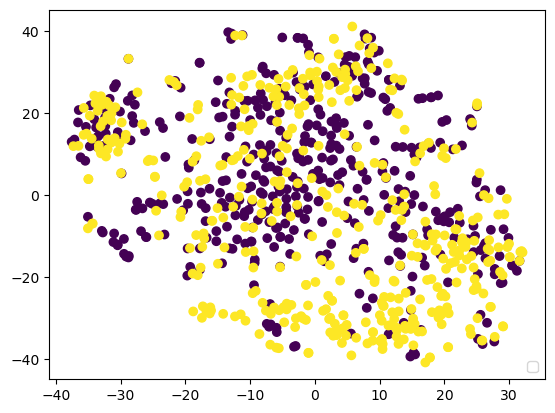

After Oversampling
Final_Ytrain
 0  
0.0    434
1.0    434
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.988479262672811
Training MCC Score: 0.9769585253456221
Training F1 Score: 0.988479262672811
Training AUC VALUE: 0.9992779630062223
Training kappa Score: 0.9769585253456221
Training Precision: 0.988479262672811
Training Recall: 0.988479262672811
Training Sensitivity: 0.988479262672811
Training Specificity: 0.988479262672811
Training CCR: 0.988479262672811
Training PPV: 0.988479262672811


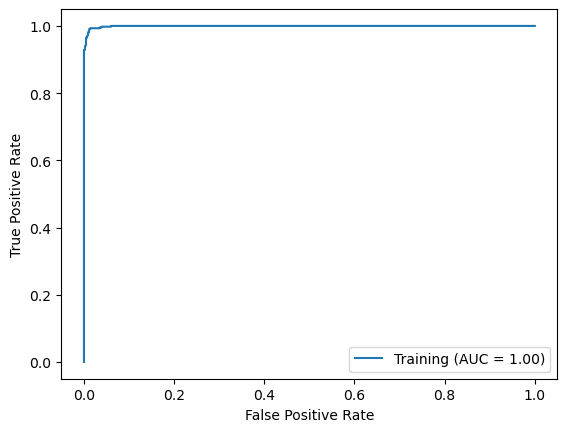

Testing Accuracy: 0.5599022004889975
Testing MCC Score: 0.14170515211353785
Testing F1 Score: 0.5325120650241301
Testing AUC VALUE: 0.6001891551071878
Testing kappa Score: 0.12296585737771315
Testing Precision: 0.8078817733990148
Testing Recall: 0.5377049180327869
Testing Sensitivity: 0.5377049180327869
Testing Specificity: 0.625
Testing CCR: 0.5599022004889975
Testing PPV: 0.8078817733990148


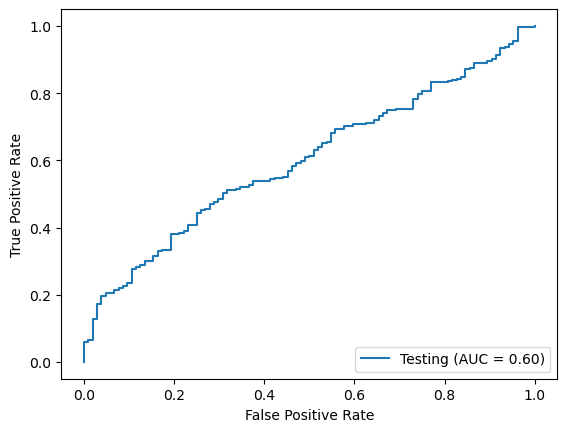

Fold # 1 Random Seed: 921
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 43
After filteration
Train shape
 (1633, 43) 
Test shape
 (409, 43)
Before Oversampling
y_train_filtered
 1.0    1203
0.0     430
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


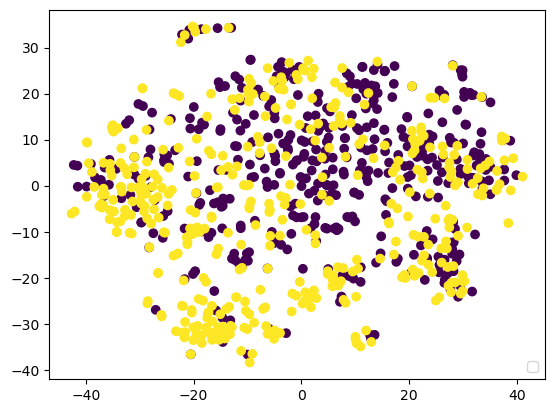

After Oversampling
Final_Ytrain
 0  
0.0    430
1.0    430
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9511627906976744
Training MCC Score: 0.9023353417006154
Training F1 Score: 0.951162526568559
Training AUC VALUE: 0.9864764737696051
Training kappa Score: 0.9023255813953488
Training Precision: 0.9532710280373832
Training Recall: 0.9488372093023256
Training Sensitivity: 0.9488372093023256
Training Specificity: 0.9534883720930233
Training CCR: 0.9511627906976744
Training PPV: 0.9532710280373832


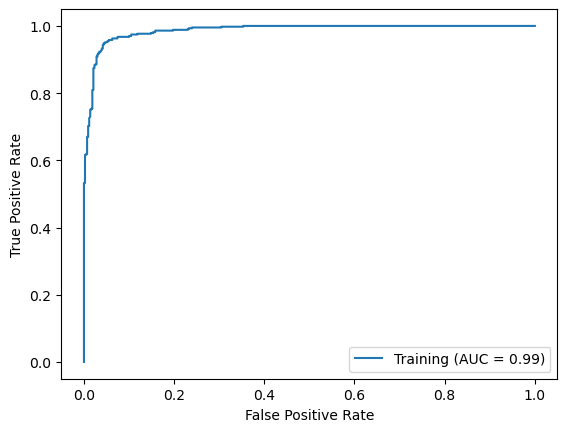

Testing Accuracy: 0.6185819070904646
Testing MCC Score: 0.20636111284455896
Testing F1 Score: 0.5819968553459118
Testing AUC VALUE: 0.6578995939461055
Testing kappa Score: 0.19145377128953767
Testing Precision: 0.8165938864628821
Testing Recall: 0.6212624584717608
Testing Sensitivity: 0.6212624584717608
Testing Specificity: 0.6111111111111112
Testing CCR: 0.6185819070904646
Testing PPV: 0.8165938864628821


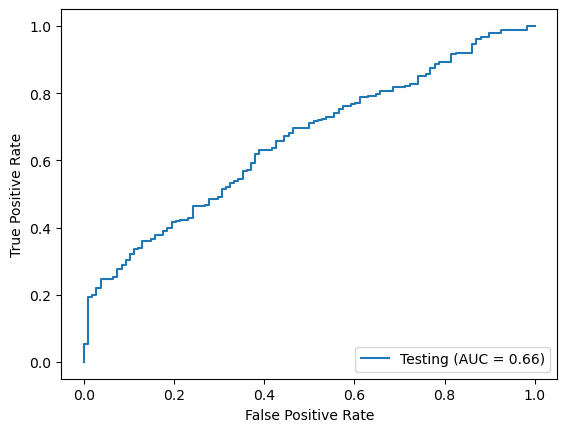

Fold # 2 Random Seed: 898
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 34
After filteration
Train shape
 (1633, 34) 
Test shape
 (409, 34)
Before Oversampling
y_train_filtered
 1.0    1204
0.0     429
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


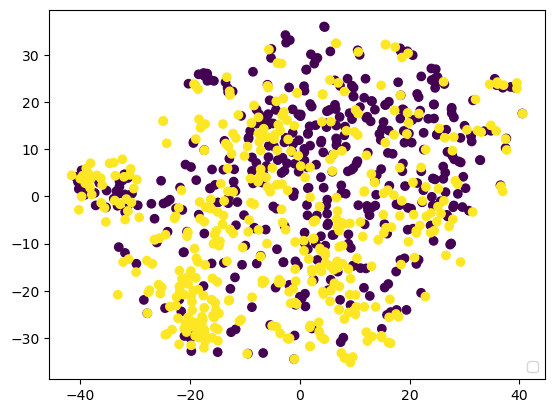

After Oversampling
Final_Ytrain
 0  
0.0    429
1.0    429
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8508158508158508
Training MCC Score: 0.7025561179767825
Training F1 Score: 0.8507177033492823
Training AUC VALUE: 0.9256796040012824
Training kappa Score: 0.7016317016317016
Training Precision: 0.8697788697788698
Training Recall: 0.8251748251748252
Training Sensitivity: 0.8251748251748252
Training Specificity: 0.8764568764568764
Training CCR: 0.8508158508158508
Training PPV: 0.8697788697788698


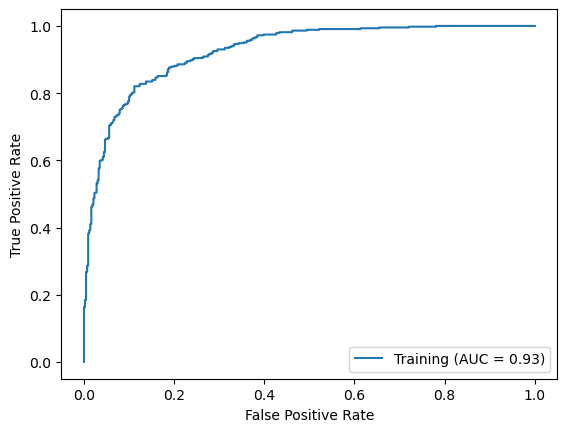

Testing Accuracy: 0.6136919315403423
Testing MCC Score: 0.19279721034810157
Testing F1 Score: 0.5766378406708595
Testing AUC VALUE: 0.6520489296636085
Testing kappa Score: 0.17961152723117935
Testing Precision: 0.808695652173913
Testing Recall: 0.62
Testing Sensitivity: 0.62
Testing Specificity: 0.5963302752293578
Testing CCR: 0.6136919315403423
Testing PPV: 0.808695652173913


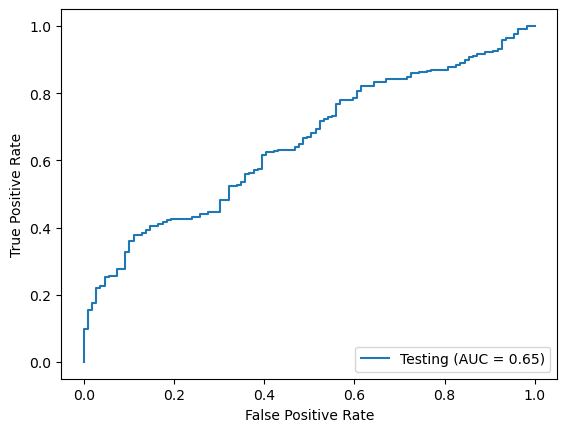

Fold # 3 Random Seed: 793
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 43
After filteration
Train shape
 (1633, 43) 
Test shape
 (409, 43)
Before Oversampling
y_train_filtered
 1.0    1198
0.0     435
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


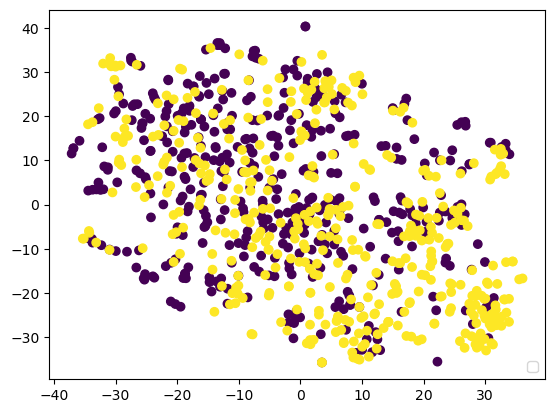

After Oversampling
Final_Ytrain
 0  
0.0    435
1.0    435
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.993103448275862
Training MCC Score: 0.9862173203597019
Training F1 Score: 0.9931034118293662
Training AUC VALUE: 0.9997859690844233
Training kappa Score: 0.9862068965517241
Training Precision: 0.9908466819221968
Training Recall: 0.9954022988505747
Training Sensitivity: 0.9954022988505747
Training Specificity: 0.9908045977011494
Training CCR: 0.993103448275862
Training PPV: 0.9908466819221968


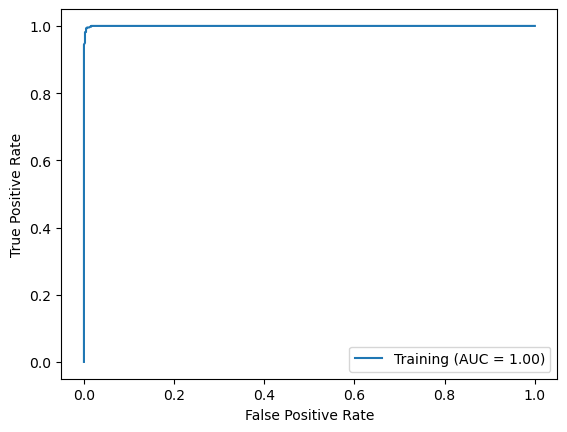

Testing Accuracy: 0.6136919315403423
Testing MCC Score: 0.18134606711980486
Testing F1 Score: 0.5695310418332
Testing AUC VALUE: 0.6668570340757662
Testing kappa Score: 0.16779992788337728
Testing Precision: 0.8162393162393162
Testing Recall: 0.6241830065359477
Testing Sensitivity: 0.6241830065359477
Testing Specificity: 0.5825242718446602
Testing CCR: 0.6136919315403423
Testing PPV: 0.8162393162393162


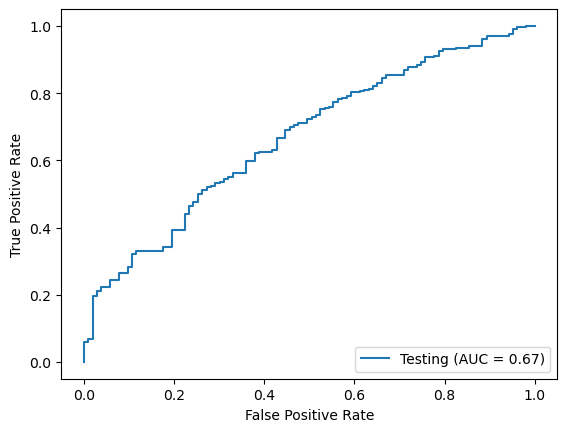

Fold # 4 Random Seed: 791
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 42
After filteration
Train shape
 (1633, 42) 
Test shape
 (409, 42)
Before Oversampling
y_train_filtered
 1.0    1199
0.0     434
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


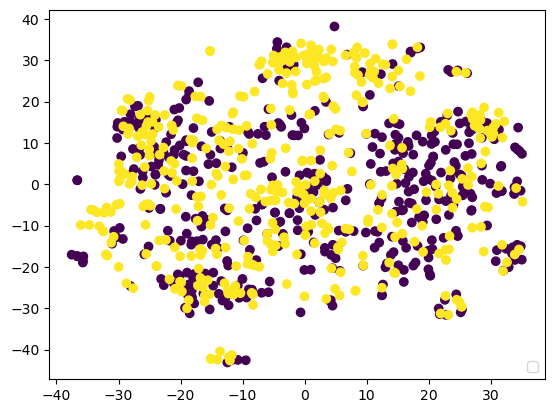

After Oversampling
Final_Ytrain
 0  
0.0    434
1.0    434
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9182027649769585
Training MCC Score: 0.8365854305321572
Training F1 Score: 0.9181939700773751
Training AUC VALUE: 0.971729066236276
Training kappa Score: 0.836405529953917
Training Precision: 0.9270588235294117
Training Recall: 0.9078341013824884
Training Sensitivity: 0.9078341013824884
Training Specificity: 0.9285714285714286
Training CCR: 0.9182027649769585
Training PPV: 0.9270588235294117


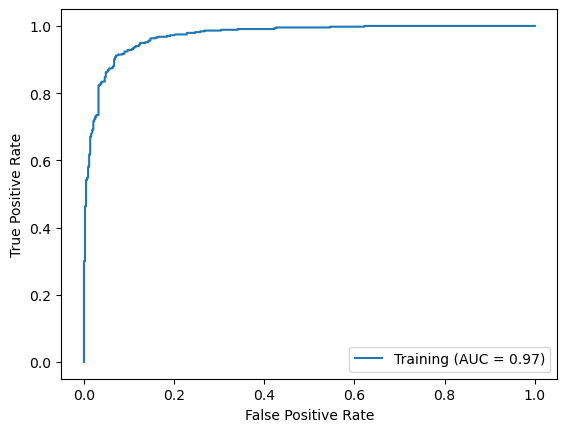

Testing Accuracy: 0.6356968215158925
Testing MCC Score: 0.20129640011764255
Testing F1 Score: 0.5857650713377788
Testing AUC VALUE: 0.6734394703656998
Testing kappa Score: 0.19067982310522047
Testing Precision: 0.8170731707317073
Testing Recall: 0.659016393442623
Testing Sensitivity: 0.659016393442623
Testing Specificity: 0.5673076923076923
Testing CCR: 0.6356968215158925
Testing PPV: 0.8170731707317073


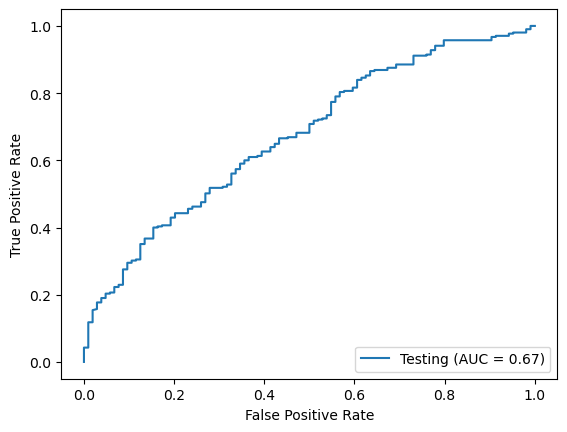

Fold # 5 Random Seed: 195
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 38
After filteration
Train shape
 (1633, 38) 
Test shape
 (409, 38)
Before Oversampling
y_train_filtered
 1.0    1198
0.0     435
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


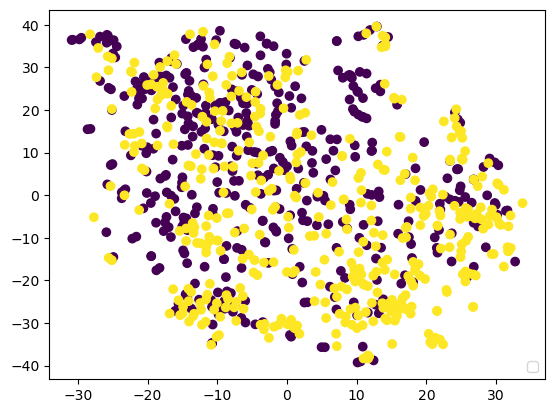

After Oversampling
Final_Ytrain
 0  
0.0    435
1.0    435
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9103448275862069
Training MCC Score: 0.8208284779106608
Training F1 Score: 0.9103372461140855
Training AUC VALUE: 0.9727731536530585
Training kappa Score: 0.8206896551724138
Training Precision: 0.9180327868852459
Training Recall: 0.9011494252873563
Training Sensitivity: 0.9011494252873563
Training Specificity: 0.9195402298850575
Training CCR: 0.9103448275862069
Training PPV: 0.9180327868852459


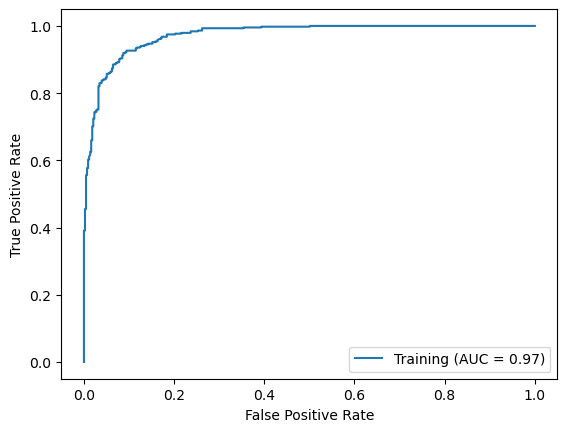

Testing Accuracy: 0.589242053789731
Testing MCC Score: 0.16272993637816266
Testing F1 Score: 0.5526329496327934
Testing AUC VALUE: 0.6452186052414494
Testing kappa Score: 0.14637115809874024
Testing Precision: 0.8136363636363636
Testing Recall: 0.5849673202614379
Testing Sensitivity: 0.5849673202614379
Testing Specificity: 0.6019417475728155
Testing CCR: 0.589242053789731
Testing PPV: 0.8136363636363636


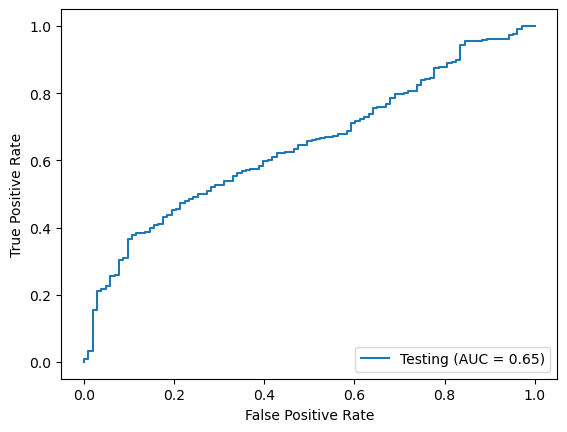

Fold # 6 Random Seed: 274
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 51
After filteration
Train shape
 (1633, 51) 
Test shape
 (409, 51)
Before Oversampling
y_train_filtered
 1.0    1191
0.0     442
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


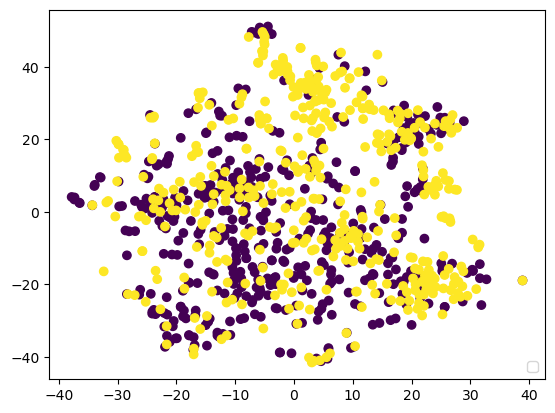

After Oversampling
Final_Ytrain
 0  
0.0    442
1.0    442
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9773755656108597
Training MCC Score: 0.9547902299207498
Training F1 Score: 0.9773751023751024
Training AUC VALUE: 0.997450912143486
Training kappa Score: 0.9547511312217195
Training Precision: 0.9730941704035875
Training Recall: 0.9819004524886877
Training Sensitivity: 0.9819004524886877
Training Specificity: 0.9728506787330317
Training CCR: 0.9773755656108597
Training PPV: 0.9730941704035875


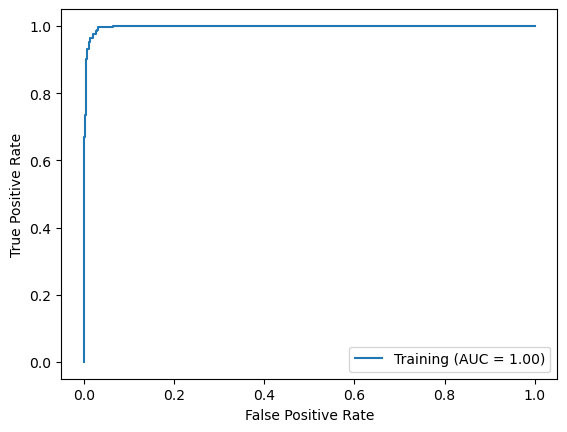

Testing Accuracy: 0.5721271393643031
Testing MCC Score: 0.10495766837705557
Testing F1 Score: 0.5240422659777499
Testing AUC VALUE: 0.6134185303514377
Testing kappa Score: 0.09370053814498269
Testing Precision: 0.8053097345132744
Testing Recall: 0.5814696485623003
Testing Sensitivity: 0.5814696485623003
Testing Specificity: 0.5416666666666666
Testing CCR: 0.5721271393643031
Testing PPV: 0.8053097345132744


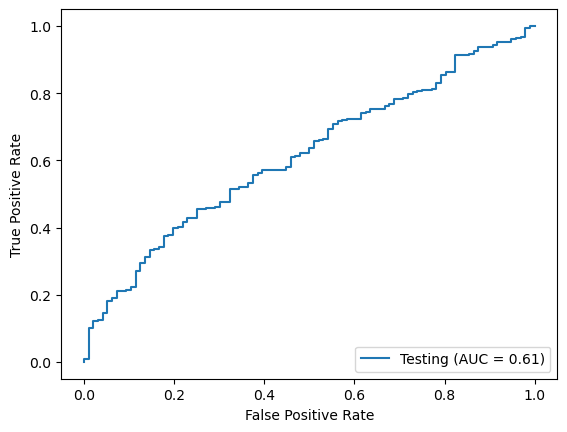

Fold # 7 Random Seed: 619
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 50
After filteration
Train shape
 (1633, 50) 
Test shape
 (409, 50)
Before Oversampling
y_train_filtered
 1.0    1208
0.0     425
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


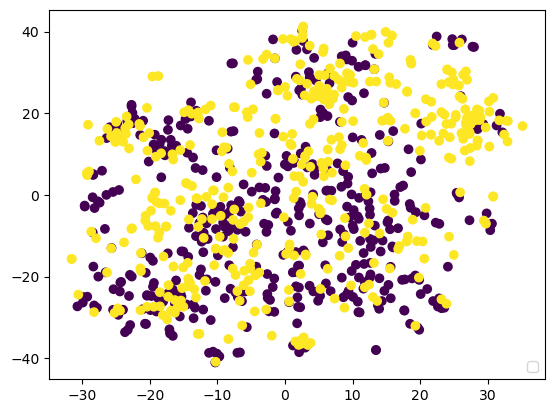

After Oversampling
Final_Ytrain
 0  
0.0    425
1.0    425
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9811764705882353
Training MCC Score: 0.9623529411764706
Training F1 Score: 0.9811764705882353
Training AUC VALUE: 0.9982117647058824
Training kappa Score: 0.9623529411764706
Training Precision: 0.9811764705882353
Training Recall: 0.9811764705882353
Training Sensitivity: 0.9811764705882353
Training Specificity: 0.9811764705882353
Training CCR: 0.9811764705882353
Training PPV: 0.9811764705882353


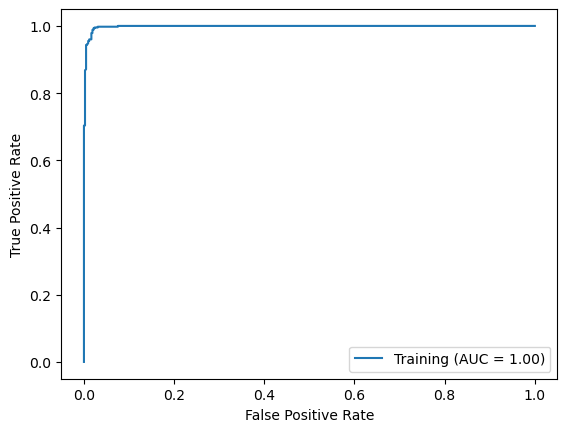

Testing Accuracy: 0.5990220048899756
Testing MCC Score: 0.17453589460412536
Testing F1 Score: 0.5671399070727929
Testing AUC VALUE: 0.6502331977995695
Testing kappa Score: 0.16230392646618053
Testing Precision: 0.7946428571428571
Testing Recall: 0.6013513513513513
Testing Sensitivity: 0.6013513513513513
Testing Specificity: 0.5929203539823009
Testing CCR: 0.5990220048899756
Testing PPV: 0.7946428571428571


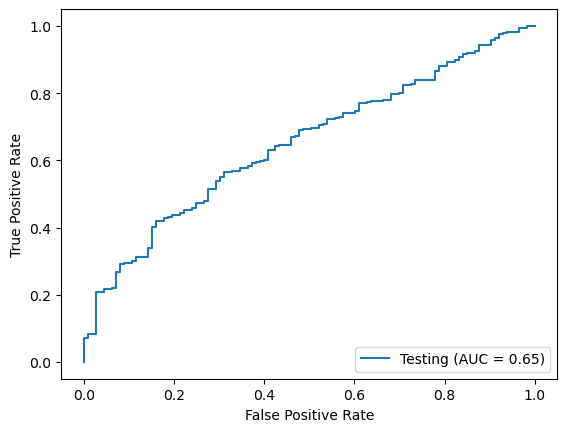

Fold # 8 Random Seed: 442
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 42
After filteration
Train shape
 (1633, 42) 
Test shape
 (409, 42)
Before Oversampling
y_train_filtered
 1.0    1197
0.0     436
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


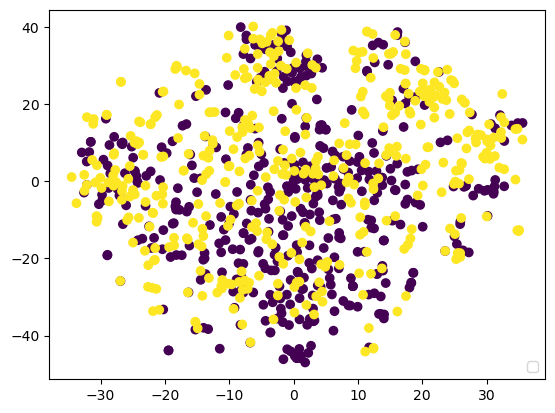

After Oversampling
Final_Ytrain
 0  
0.0    436
1.0    436
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9977064220183486
Training MCC Score: 0.9954128440366973
Training F1 Score: 0.9977064220183486
Training AUC VALUE: 0.9999868487501051
Training kappa Score: 0.9954128440366973
Training Precision: 0.9977064220183486
Training Recall: 0.9977064220183486
Training Sensitivity: 0.9977064220183486
Training Specificity: 0.9977064220183486
Training CCR: 0.9977064220183486
Training PPV: 0.9977064220183486


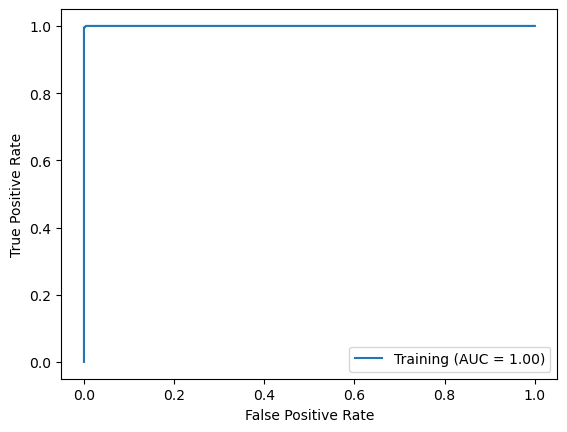

Testing Accuracy: 0.6650366748166259
Testing MCC Score: 0.3063374987467569
Testing F1 Score: 0.6273930882225813
Testing AUC VALUE: 0.7201092163249664
Testing kappa Score: 0.28165583374998393
Testing Precision: 0.8663793103448276
Testing Recall: 0.6547231270358306
Testing Sensitivity: 0.6547231270358306
Testing Specificity: 0.696078431372549
Testing CCR: 0.6650366748166259
Testing PPV: 0.8663793103448276


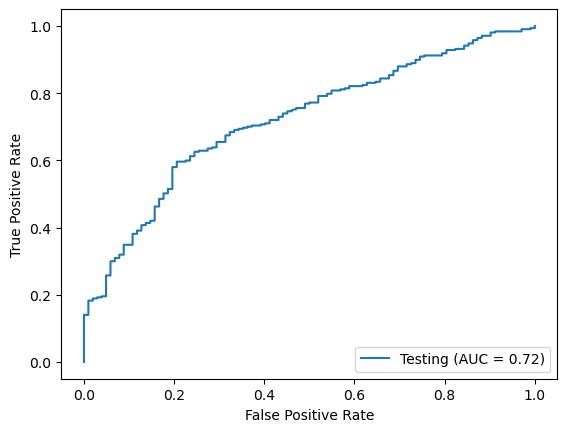

Fold # 9 Random Seed: 278
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 46
After filteration
Train shape
 (1633, 46) 
Test shape
 (409, 46)
Before Oversampling
y_train_filtered
 1.0    1206
0.0     427
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


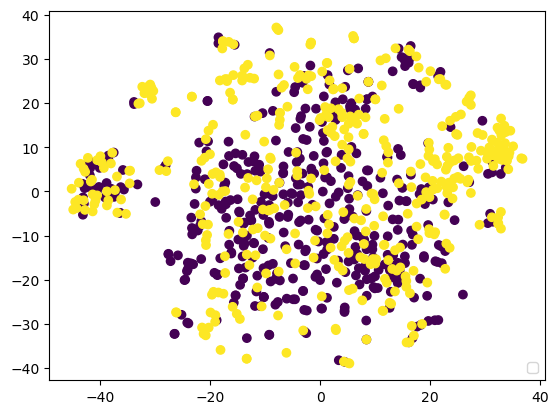

After Oversampling
Final_Ytrain
 0  
0.0    427
1.0    427
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8629976580796253
Training MCC Score: 0.7264436822591734
Training F1 Score: 0.862955378683868
Training AUC VALUE: 0.9481486762939523
Training kappa Score: 0.7259953161592505
Training Precision: 0.8762135922330098
Training Recall: 0.8454332552693209
Training Sensitivity: 0.8454332552693209
Training Specificity: 0.8805620608899297
Training CCR: 0.8629976580796253
Training PPV: 0.8762135922330098


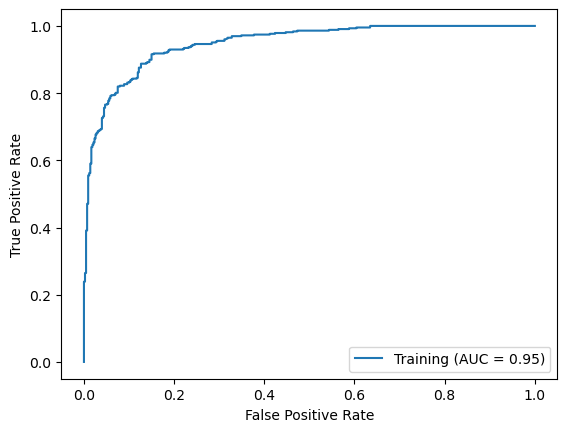

Testing Accuracy: 0.6161369193154034
Testing MCC Score: 0.19139191802358382
Testing F1 Score: 0.5786465612840147
Testing AUC VALUE: 0.6533647741701433
Testing kappa Score: 0.1800257945882443
Testing Precision: 0.8025751072961373
Testing Recall: 0.62751677852349
Testing Sensitivity: 0.62751677852349
Testing Specificity: 0.5855855855855856
Testing CCR: 0.6161369193154034
Testing PPV: 0.8025751072961373


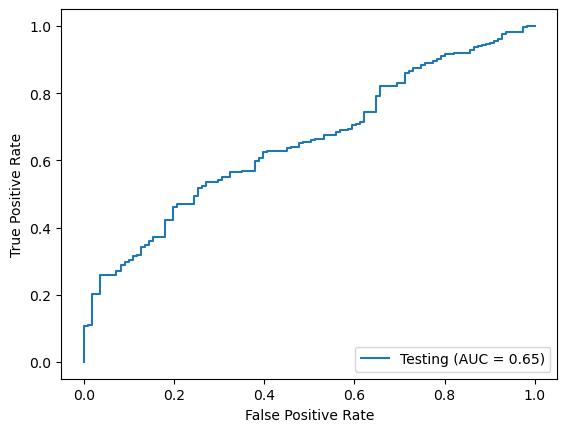

Fold # 10 Random Seed: 165
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 41
After filteration
Train shape
 (1633, 41) 
Test shape
 (409, 41)
Before Oversampling
y_train_filtered
 1.0    1207
0.0     426
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


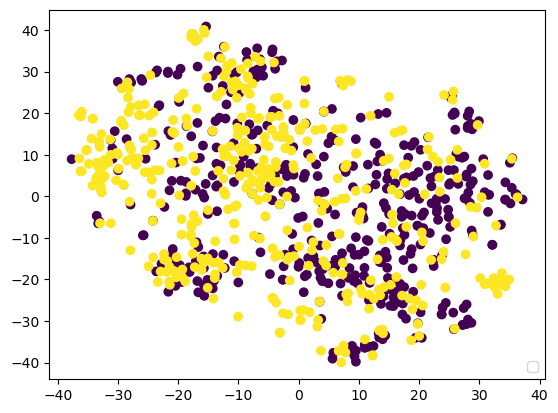

After Oversampling
Final_Ytrain
 0  
0.0    426
1.0    426
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9413145539906104
Training MCC Score: 0.8828723891992799
Training F1 Score: 0.94130646841296
Training AUC VALUE: 0.9851936344199784
Training kappa Score: 0.8826291079812206
Training Precision: 0.9519230769230769
Training Recall: 0.9295774647887324
Training Sensitivity: 0.9295774647887324
Training Specificity: 0.9530516431924883
Training CCR: 0.9413145539906104
Training PPV: 0.9519230769230769


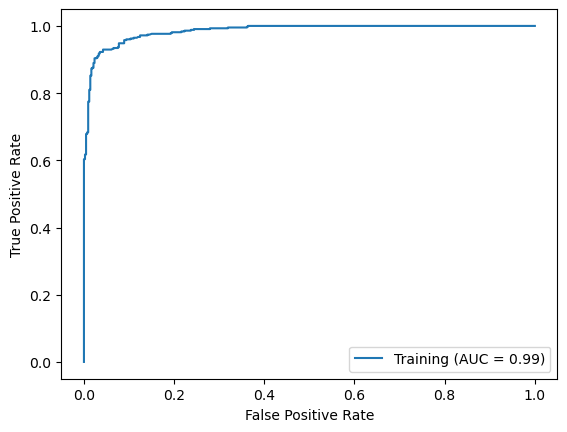

Testing Accuracy: 0.6039119804400978
Testing MCC Score: 0.2024023447763742
Testing F1 Score: 0.575965082940815
Testing AUC VALUE: 0.6480579605579606
Testing kappa Score: 0.18529903600236097
Testing Precision: 0.8110599078341014
Testing Recall: 0.5925925925925926
Testing Sensitivity: 0.5925925925925926
Testing Specificity: 0.6339285714285714
Testing CCR: 0.6039119804400978
Testing PPV: 0.8110599078341014


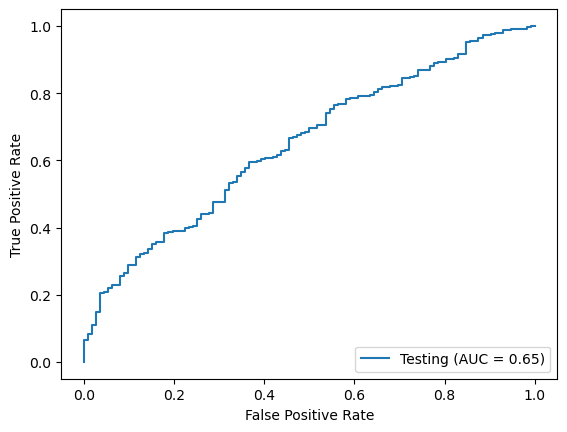

Fold # 11 Random Seed: 448
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 43
After filteration
Train shape
 (1633, 43) 
Test shape
 (409, 43)
Before Oversampling
y_train_filtered
 1.0    1206
0.0     427
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


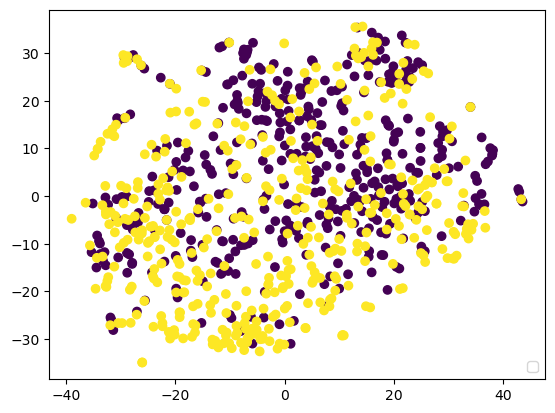

After Oversampling
Final_Ytrain
 0  
0.0    427
1.0    427
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8711943793911007
Training MCC Score: 0.7447534510551755
Training F1 Score: 0.8709898923313557
Training AUC VALUE: 0.9576671840464216
Training kappa Score: 0.7423887587822013
Training Precision: 0.9033078880407125
Training Recall: 0.8313817330210773
Training Sensitivity: 0.8313817330210773
Training Specificity: 0.9110070257611241
Training CCR: 0.8711943793911007
Training PPV: 0.9033078880407125


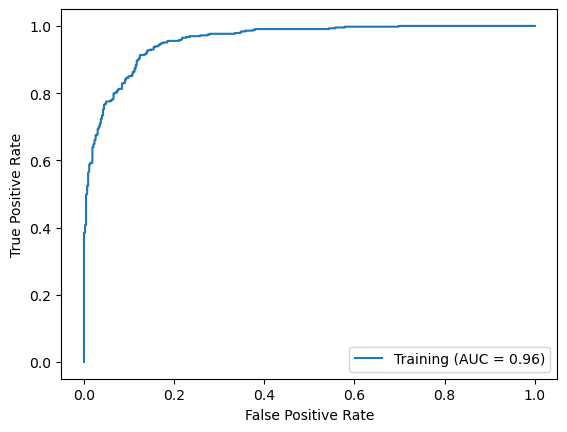

Testing Accuracy: 0.6259168704156479
Testing MCC Score: 0.2819076096543368
Testing F1 Score: 0.6050553819937518
Testing AUC VALUE: 0.6977447245903622
Testing kappa Score: 0.25099644511472585
Testing Precision: 0.8536585365853658
Testing Recall: 0.587248322147651
Testing Sensitivity: 0.587248322147651
Testing Specificity: 0.7297297297297297
Testing CCR: 0.6259168704156479
Testing PPV: 0.8536585365853658


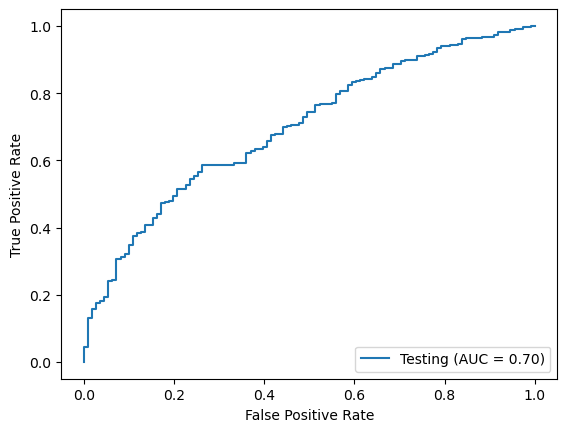

Fold # 12 Random Seed: 288
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 40
After filteration
Train shape
 (1633, 40) 
Test shape
 (409, 40)
Before Oversampling
y_train_filtered
 1.0    1187
0.0     446
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


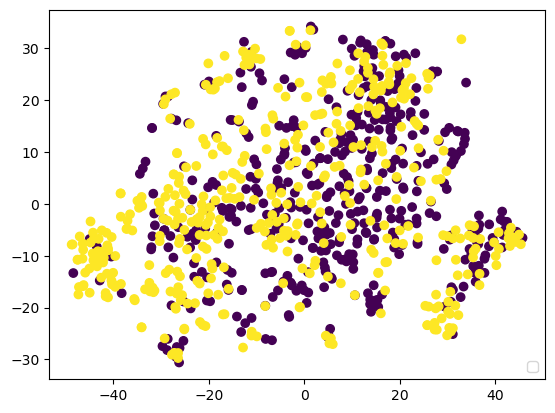

After Oversampling
Final_Ytrain
 0  
0.0    446
1.0    446
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9360986547085202
Training MCC Score: 0.8725680572113714
Training F1 Score: 0.9360850791016915
Training AUC VALUE: 0.9834754368678236
Training kappa Score: 0.8721973094170403
Training Precision: 0.9491916859122402
Training Recall: 0.92152466367713
Training Sensitivity: 0.92152466367713
Training Specificity: 0.9506726457399103
Training CCR: 0.9360986547085202
Training PPV: 0.9491916859122402


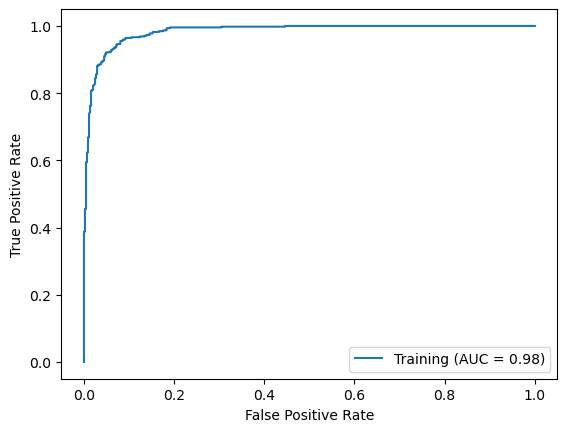

Testing Accuracy: 0.5941320293398533
Testing MCC Score: 0.1728547845884162
Testing F1 Score: 0.5492963356346257
Testing AUC VALUE: 0.6476477849403374
Testing kappa Score: 0.1505605044540086
Testing Precision: 0.8416289592760181
Testing Recall: 0.5867507886435331
Testing Sensitivity: 0.5867507886435331
Testing Specificity: 0.6195652173913043
Testing CCR: 0.5941320293398533
Testing PPV: 0.8416289592760181


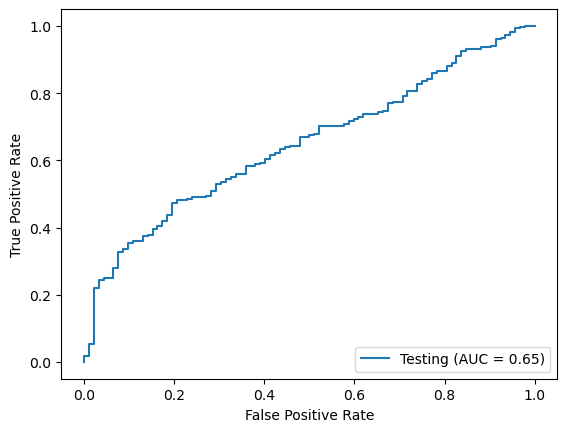

Fold # 13 Random Seed: 582
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 41
After filteration
Train shape
 (1633, 41) 
Test shape
 (409, 41)
Before Oversampling
y_train_filtered
 1.0    1201
0.0     432
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


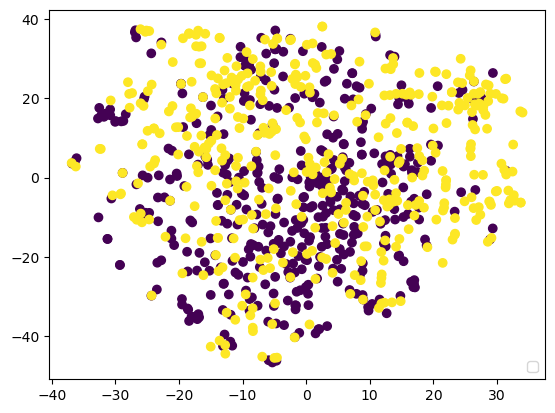

After Oversampling
Final_Ytrain
 0  
0.0    432
1.0    432
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9398148148148148
Training MCC Score: 0.8807724907768714
Training F1 Score: 0.9397757676820213
Training AUC VALUE: 0.98649155521262
Training kappa Score: 0.8796296296296297
Training Precision: 0.9634146341463414
Training Recall: 0.9143518518518519
Training Sensitivity: 0.9143518518518519
Training Specificity: 0.9652777777777778
Training CCR: 0.9398148148148148
Training PPV: 0.9634146341463414


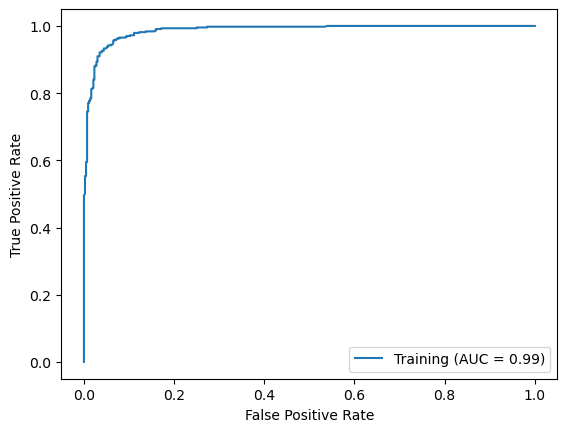

Testing Accuracy: 0.6039119804400978
Testing MCC Score: 0.21448593215093623
Testing F1 Score: 0.5748113352841522
Testing AUC VALUE: 0.6676318575253752
Testing kappa Score: 0.19164043627845695
Testing Precision: 0.8309859154929577
Testing Recall: 0.5841584158415841
Testing Sensitivity: 0.5841584158415841
Testing Specificity: 0.660377358490566
Testing CCR: 0.6039119804400978
Testing PPV: 0.8309859154929577


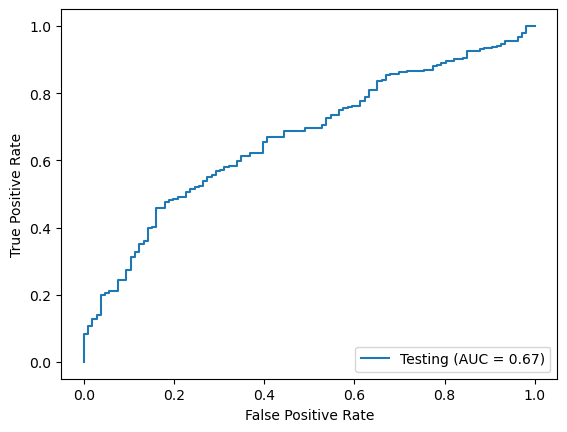

Fold # 14 Random Seed: 422
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 40
After filteration
Train shape
 (1633, 40) 
Test shape
 (409, 40)
Before Oversampling
y_train_filtered
 1.0    1213
0.0     420
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


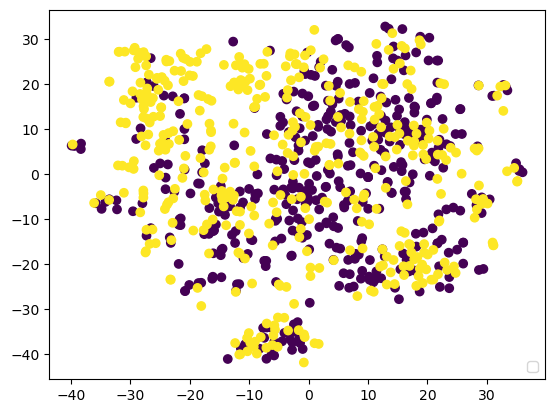

After Oversampling
Final_Ytrain
 0  
0.0    420
1.0    420
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9273809523809524
Training MCC Score: 0.8548806464315423
Training F1 Score: 0.9273759090413024
Training AUC VALUE: 0.9818225623582766
Training kappa Score: 0.8547619047619047
Training Precision: 0.9346246973365617
Training Recall: 0.919047619047619
Training Sensitivity: 0.919047619047619
Training Specificity: 0.9357142857142857
Training CCR: 0.9273809523809524
Training PPV: 0.9346246973365617


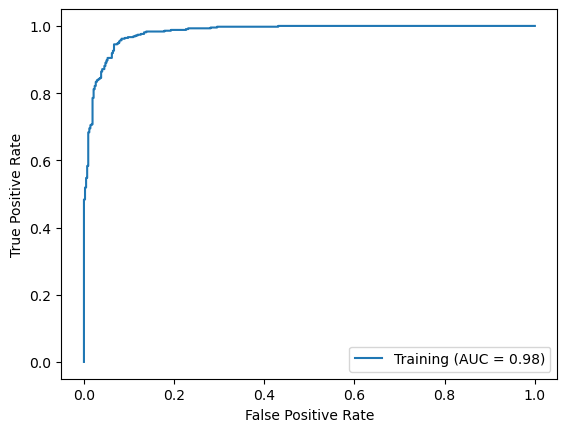

Testing Accuracy: 0.60880195599022
Testing MCC Score: 0.15503549284724052
Testing F1 Score: 0.5684971250725326
Testing AUC VALUE: 0.6236530956957307
Testing kappa Score: 0.14990906729020526
Testing Precision: 0.7695473251028807
Testing Recall: 0.6426116838487973
Testing Sensitivity: 0.6426116838487973
Testing Specificity: 0.5254237288135594
Testing CCR: 0.60880195599022
Testing PPV: 0.7695473251028807


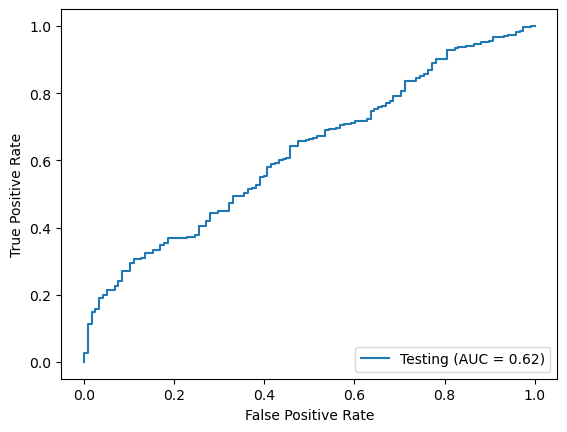

Fold # 15 Random Seed: 124
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 41
After filteration
Train shape
 (1633, 41) 
Test shape
 (409, 41)
Before Oversampling
y_train_filtered
 1.0    1191
0.0     442
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


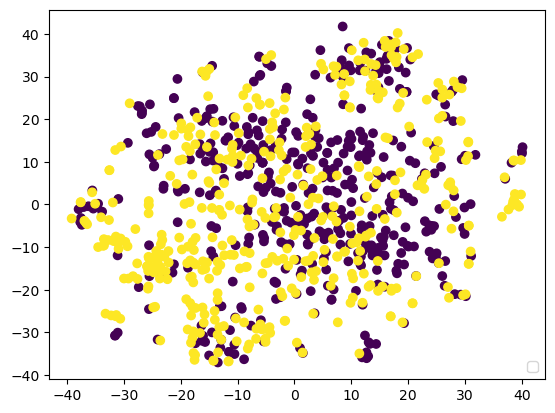

After Oversampling
Final_Ytrain
 0  
0.0    442
1.0    442
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9864253393665159
Training MCC Score: 0.9728506787330317
Training F1 Score: 0.9864253393665159
Training AUC VALUE: 0.9994446264409
Training kappa Score: 0.9728506787330317
Training Precision: 0.9864253393665159
Training Recall: 0.9864253393665159
Training Sensitivity: 0.9864253393665159
Training Specificity: 0.9864253393665159
Training CCR: 0.9864253393665159
Training PPV: 0.9864253393665159


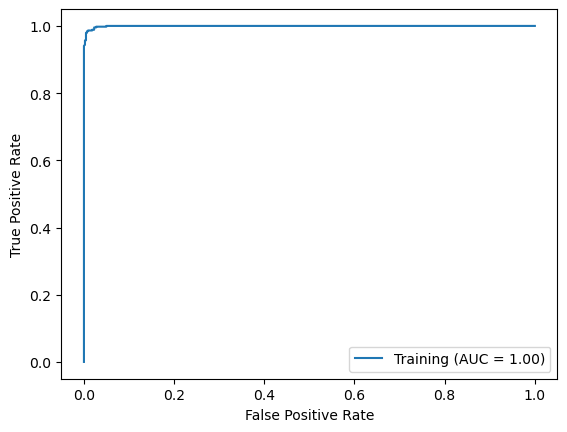

Testing Accuracy: 0.58679706601467
Testing MCC Score: 0.18802943558223004
Testing F1 Score: 0.5519914444048353
Testing AUC VALUE: 0.6719914802981894
Testing kappa Score: 0.16163110846968354
Testing Precision: 0.8428571428571429
Testing Recall: 0.5654952076677316
Testing Sensitivity: 0.5654952076677316
Testing Specificity: 0.65625
Testing CCR: 0.58679706601467
Testing PPV: 0.8428571428571429


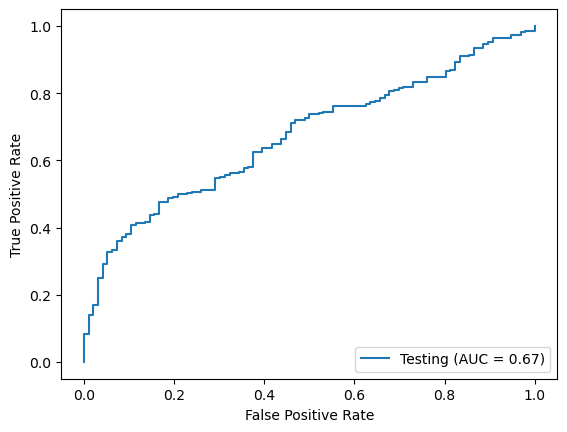

Fold # 16 Random Seed: 15
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 42
After filteration
Train shape
 (1633, 42) 
Test shape
 (409, 42)
Before Oversampling
y_train_filtered
 1.0    1202
0.0     431
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


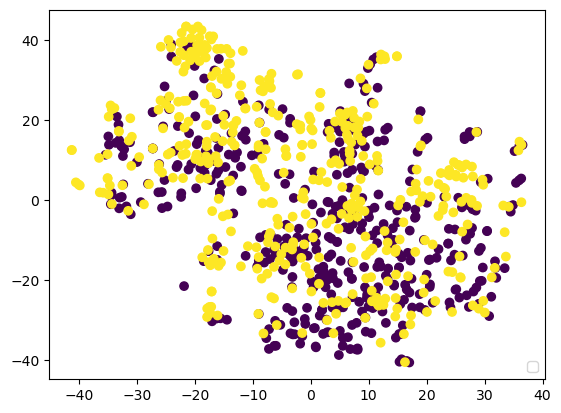

After Oversampling
Final_Ytrain
 0  
0.0    431
1.0    431
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9385150812064965
Training MCC Score: 0.8770891844020265
Training F1 Score: 0.9385130124532481
Training AUC VALUE: 0.9817561274971603
Training kappa Score: 0.877030162412993
Training Precision: 0.9436619718309859
Training Recall: 0.9327146171693735
Training Sensitivity: 0.9327146171693735
Training Specificity: 0.9443155452436195
Training CCR: 0.9385150812064965
Training PPV: 0.9436619718309859


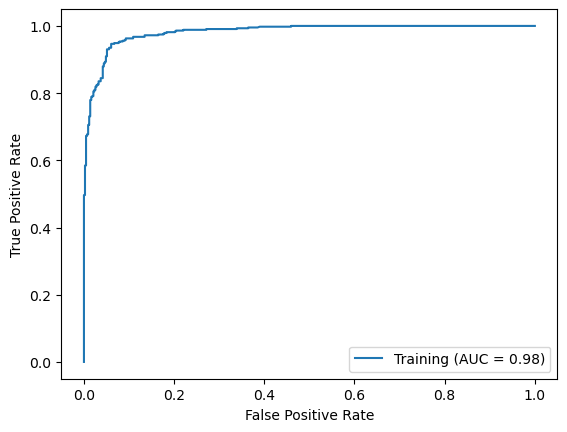

Testing Accuracy: 0.6234718826405868
Testing MCC Score: 0.20482937980935342
Testing F1 Score: 0.5832936381920186
Testing AUC VALUE: 0.6822739369932538
Testing kappa Score: 0.19132600657354148
Testing Precision: 0.8162393162393162
Testing Recall: 0.6324503311258278
Testing Sensitivity: 0.6324503311258278
Testing Specificity: 0.5981308411214953
Testing CCR: 0.6234718826405868
Testing PPV: 0.8162393162393162


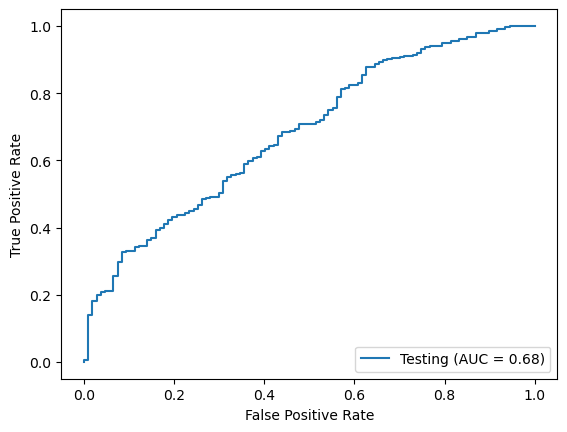

Fold # 17 Random Seed: 754
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 41
After filteration
Train shape
 (1633, 41) 
Test shape
 (409, 41)
Before Oversampling
y_train_filtered
 1.0    1193
0.0     440
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


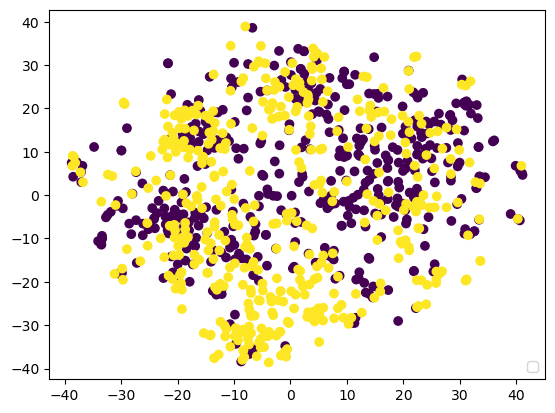

After Oversampling
Final_Ytrain
 0  
0.0    440
1.0    440
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9613636363636363
Training MCC Score: 0.922765404316963
Training F1 Score: 0.9613628380751669
Training AUC VALUE: 0.9950439049586777
Training kappa Score: 0.9227272727272727
Training Precision: 0.9655963302752294
Training Recall: 0.9568181818181818
Training Sensitivity: 0.9568181818181818
Training Specificity: 0.9659090909090909
Training CCR: 0.9613636363636363
Training PPV: 0.9655963302752294


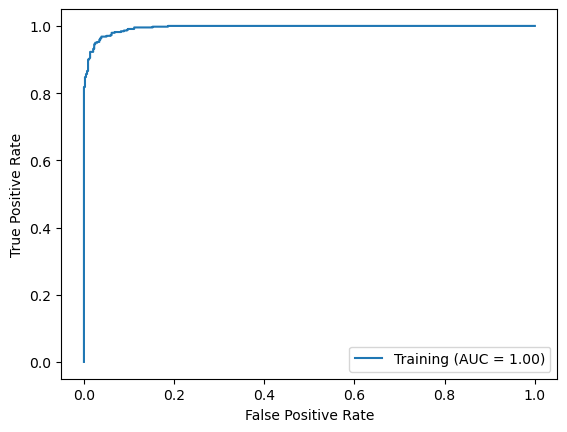

Testing Accuracy: 0.5819070904645477
Testing MCC Score: 0.15783414623304334
Testing F1 Score: 0.5439464778262486
Testing AUC VALUE: 0.6423977951309141
Testing kappa Score: 0.1385867891761401
Testing Precision: 0.8240740740740741
Testing Recall: 0.572347266881029
Testing Sensitivity: 0.572347266881029
Testing Specificity: 0.6122448979591837
Testing CCR: 0.5819070904645477
Testing PPV: 0.8240740740740741


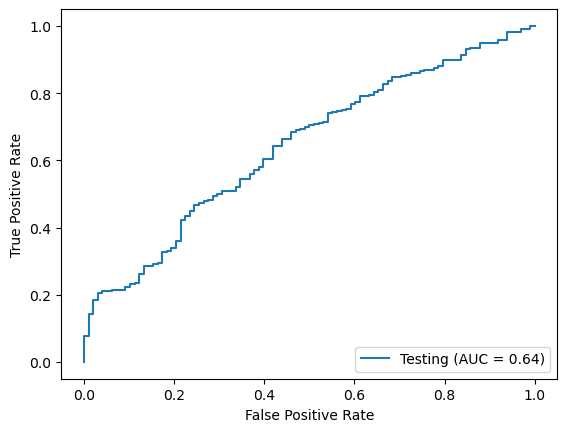

Fold # 18 Random Seed: 88
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 48
After filteration
Train shape
 (1633, 48) 
Test shape
 (409, 48)
Before Oversampling
y_train_filtered
 1.0    1208
0.0     425
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


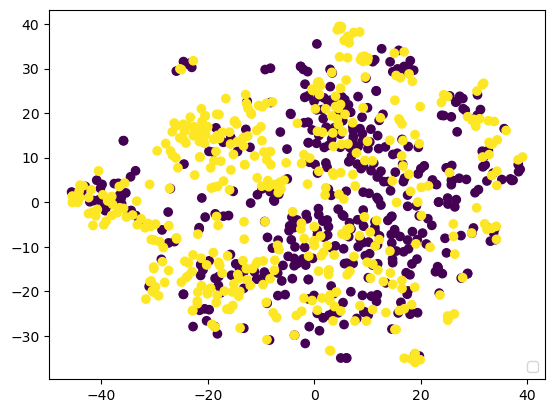

After Oversampling
Final_Ytrain
 0  
0.0    425
1.0    425
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9505882352941176
Training MCC Score: 0.9012662898360169
Training F1 Score: 0.9505857731319485
Training AUC VALUE: 0.9906989619377162
Training kappa Score: 0.9011764705882352
Training Precision: 0.9570405727923628
Training Recall: 0.9435294117647058
Training Sensitivity: 0.9435294117647058
Training Specificity: 0.9576470588235294
Training CCR: 0.9505882352941176
Training PPV: 0.9570405727923628


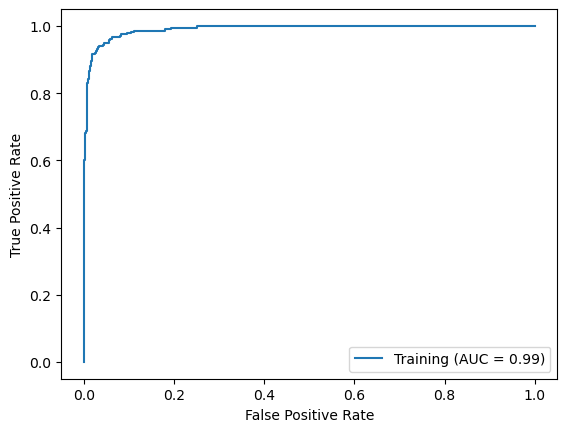

Testing Accuracy: 0.6063569682151589
Testing MCC Score: 0.15567817663105202
Testing F1 Score: 0.5650804134605858
Testing AUC VALUE: 0.6437455154269314
Testing kappa Score: 0.148434570072549
Testing Precision: 0.7824267782426778
Testing Recall: 0.6317567567567568
Testing Sensitivity: 0.6317567567567568
Testing Specificity: 0.5398230088495575
Testing CCR: 0.6063569682151589
Testing PPV: 0.7824267782426778


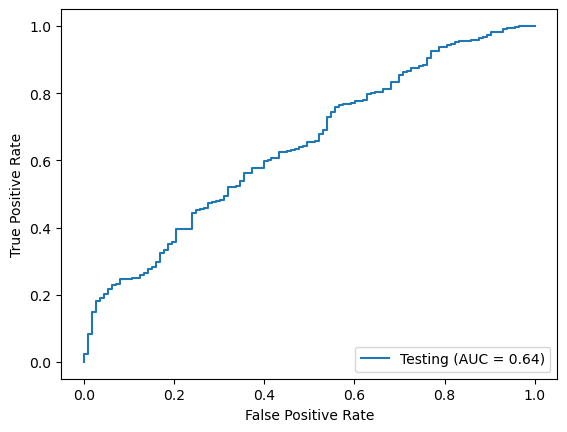

Fold # 19 Random Seed: 492
Before filteration
Train shape
 (1633, 3200) 
Test shape
 (409, 3200)
# of Features selected: 39
After filteration
Train shape
 (1633, 39) 
Test shape
 (409, 39)
Before Oversampling
y_train_filtered
 1.0    1204
0.0     429
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


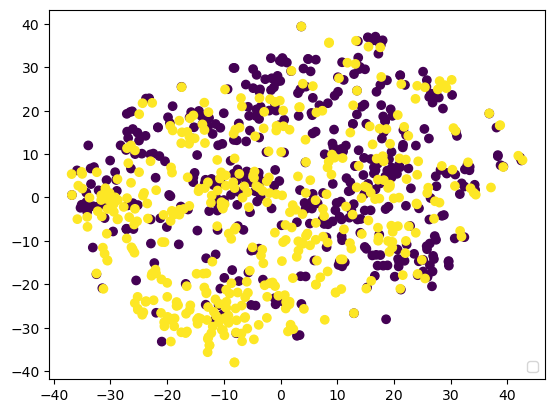

After Oversampling
Final_Ytrain
 0  
0.0    429
1.0    429
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8962703962703963
Training MCC Score: 0.7933192300057174
Training F1 Score: 0.8962195044053911
Training AUC VALUE: 0.9617340701256786
Training kappa Score: 0.7925407925407926
Training Precision: 0.9146341463414634
Training Recall: 0.8741258741258742
Training Sensitivity: 0.8741258741258742
Training Specificity: 0.9184149184149184
Training CCR: 0.8962703962703963
Training PPV: 0.9146341463414634


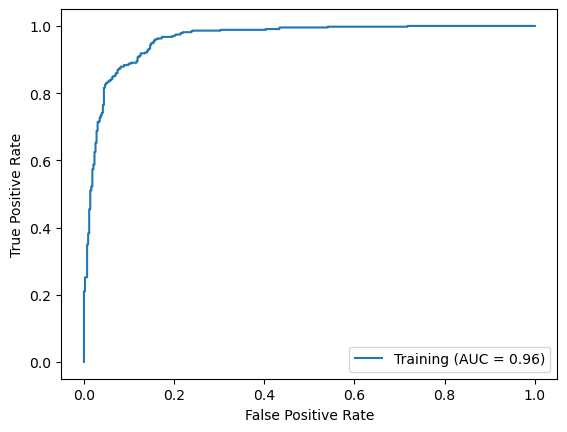

Testing Accuracy: 0.5916870415647921
Testing MCC Score: 0.24276845327400415
Testing F1 Score: 0.5745872182464795
Testing AUC VALUE: 0.683914373088685
Testing kappa Score: 0.20779642538187637
Testing Precision: 0.8481675392670157
Testing Recall: 0.54
Testing Sensitivity: 0.54
Testing Specificity: 0.7339449541284404
Testing CCR: 0.5916870415647921
Testing PPV: 0.8481675392670157


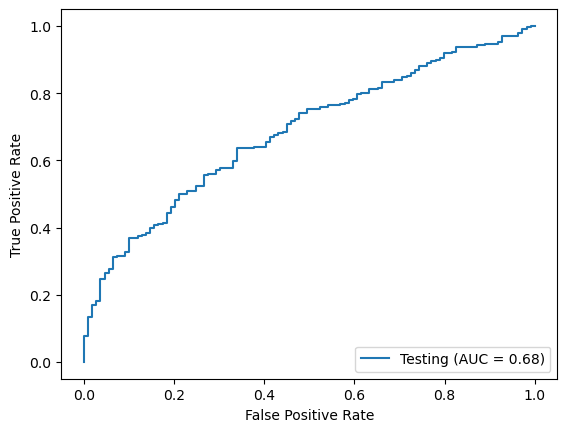

In [29]:
Train_Fold_outs=[]
Test_Fold_outs=[]
Best_params=[]
features = []
models=[]

#this chunk runs 20 iterations of the 5-Cross Validation of the pre-defined grid for the model
for i in range(20):
    #print('Fold #',i)   
    seed = random.randint(0, 1000)
    print('Fold #', i, "Random Seed:", seed)
    
    # Split Data
    X_train, X_test,y_train,y_test = train_test_split(Train,Train["status"] ,test_size=0.20, shuffle = True, random_state=seed)
    
    #Drop smiles,status from training,testing data
    x_train = X_train.drop(['status','smiles'], axis=1)
    x_test = X_test.drop(['status','smiles'], axis=1)

    #Feature selection
    x_train_filtered,x_test_filtered,y_train_filtered,y_test_filtered,selected_features = Boruta_Filteration(x_train,y_train,x_test,y_test)
    features.append(selected_features)
    
    y_train_filtered = pd.Series(y_train_filtered)

    print('Before Oversampling\ny_train_filtered\n',y_train_filtered.value_counts())
    #Oversampling
    Final_Xtrain,Final_Ytrain = Smote(x_train_filtered,y_train_filtered)
    print('After Oversampling\nFinal_Ytrain\n',Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)
    
    #Hyperparameter Tuning
    Parameters = HPTing_Model(Final_Xtrain,Final_Ytrain)
    
    #save best parameters
    Best_params.append(Parameters.best_estimator_.get_params())
    
    #build the tuned model
    #edit the parameters here according to your defined parameter space and model's grid
    rf = RandomForestClassifier(max_features=Parameters.best_estimator_.get_params()['max_features'],
                        max_depth=Parameters.best_estimator_.get_params()['max_depth'],
                        min_samples_split=Parameters.best_estimator_.get_params()['min_samples_split'],
                        min_samples_leaf=Parameters.best_estimator_.get_params()['min_samples_leaf'],
                        bootstrap=Parameters.best_estimator_.get_params()['bootstrap'],
                        n_estimators=Parameters.best_estimator_.get_params()['n_estimators'])

    
    #fit the built model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models.append(rf)

    #Training Predictions for the model
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)

    #Save training metrics
    Train_Fold_outs.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain,'Training'))

    #Testing Predictions for the model
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)

    #Save testing metrics
    Test_Fold_outs.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered,'Testing'))

In [30]:
#Analyse the testing metrics sorted by descending Testing Accuracy
pd.DataFrame.from_dict(Test_Fold_outs).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
8,0.665037,0.306337,0.627393,0.720109,0.281656,0.866379,0.654723,0.654723,0.696078,0.665037,0.866379
11,0.625917,0.281908,0.605055,0.697745,0.250996,0.853659,0.587248,0.587248,0.729730,0.625917,0.853659
19,0.591687,0.242768,0.574587,0.683914,0.207796,0.848168,0.540000,0.540000,0.733945,0.591687,0.848168
13,0.603912,0.214486,0.574811,0.667632,0.191640,0.830986,0.584158,0.584158,0.660377,0.603912,0.830986
1,0.618582,0.206361,0.581997,0.657900,0.191454,0.816594,0.621262,0.621262,0.611111,0.618582,0.816594
16,0.623472,0.204829,0.583294,0.682274,0.191326,0.816239,0.632450,0.632450,0.598131,0.623472,0.816239
4,0.635697,0.201296,0.585765,0.673439,0.190680,0.817073,0.659016,0.659016,0.567308,0.635697,0.817073
10,0.603912,0.202402,0.575965,0.648058,0.185299,0.811060,0.592593,0.592593,0.633929,0.603912,0.811060
9,0.616137,0.191392,0.578647,0.653365,0.180026,0.802575,0.627517,0.627517,0.585586,0.616137,0.802575
2,0.613692,0.192797,0.576638,0.652049,0.179612,0.808696,0.620000,0.620000,0.596330,0.613692,0.808696


In [31]:
#View the best parameters
pd.DataFrame.from_dict(Best_params)

,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start
0,False,0.0,None,gini,80.0,log2,None,None,0.0,1,29,0.0,67,None,False,None,0,False
1,True,0.0,None,gini,20.0,log2,None,None,0.0,6,16,0.0,67,None,False,None,0,False
2,True,0.0,None,gini,90.0,0.5,None,None,0.0,19,3,0.0,78,None,False,None,0,False
3,False,0.0,None,gini,60.0,log2,None,None,0.0,6,3,0.0,34,None,False,None,0,False
4,False,0.0,None,gini,10.0,sqrt,None,None,0.0,18,22,0.0,78,None,False,None,0,False
5,True,0.0,None,gini,20.0,None,None,None,0.0,12,25,0.0,89,None,False,None,0,False
6,False,0.0,None,gini,60.0,0.5,None,None,0.0,12,20,0.0,89,None,False,None,0,False
7,False,0.0,None,gini,20.0,log2,None,None,0.0,7,20,0.0,56,None,False,None,0,False
8,False,0.0,None,gini,110.0,sqrt,None,None,0.0,5,13,0.0,89,None,False,None,0,False
9,True,0.0,None,gini,10.0,sqrt,None,None,0.0,14,23,0.0,78,None,False,None,0,False


In [32]:
#View length of the features selected for the top performing/most stable (selected) model (1st here)
len(features[8])

42

In [33]:
#Save the feature names
pd.DataFrame(features[8]).to_csv('AID_1259408_features.csv',index=False)

In [34]:
#save the best parameters of the chosen model
with open('AID_1259408_best_params_RF.csv', 'w') as f:  # You will need 'wb' mode in Python 2.x
    w = csv.DictWriter(f, Best_params[8].keys())
    w.writeheader()
    w.writerow(Best_params[8])

In [35]:
"""
#Randomly split the data into testing and validation for each fold
def Test_valid_split(Set3,frac,seed):
    Fraction=frac
    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))
    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]
    Valid=Set3.T[Valid_index].T
    print('Test set size:',len(Test),'\nValid set size:',len(Valid))
    return Test,Valid
"""

"\n#Randomly split the data into testing and validation for each fold\ndef Test_valid_split(Set3,frac,seed):\n    Fraction=frac\n    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))\n    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]\n    Valid=Set3.T[Valid_index].T\n    print('Test set size:',len(Test),'\nValid set size:',len(Valid))\n    return Test,Valid\n"

In [36]:
def Test_valid_split(Set3, frac, seed):
    Fraction = frac
    Test_1 = Set3[Set3['status'] == 1].sample(frac=Fraction, random_state=1)
    Test_0 = Set3[Set3['status'] == 0].sample(frac=Fraction, random_state=seed)
    
    # 使用 pd.concat 代替 append
    Test = pd.concat([Test_1, Test_0])
    
    Valid_index = [item for item in list(Set3.index) if item not in list(Test.index)]
    Valid = Set3.T[Valid_index].T
    print('Test set size:', len(Test), '\nValid set size:', len(Valid))
    
    return Test, Valid

In [37]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('AID_1259408_features.csv')

# 假设第一列名为 'Features'
f_list = df['Features'].tolist()

# 输出 f_list 确认结果
print(f_list)

['A4_93', 'B2_38', 'B3_66', 'B5_15', 'B5_91', 'C1_79', 'C1_103', 'C2_43', 'C2_64', 'C3_64', 'D1_6', 'D1_30', 'D1_60', 'D1_72', 'D2_8', 'D2_92', 'D2_109', 'D3_17', 'D3_22', 'E1_22', 'E1_75', 'E1_82', 'E1_115', 'E2_13', 'E2_39', 'E2_53', 'E2_70', 'E2_75', 'E2_77', 'E2_95', 'E2_121', 'E3_48', 'E3_111', 'E4_5', 'E4_6', 'E4_64', 'E4_70', 'E4_111', 'E5_3', 'E5_54', 'E5_64', 'E5_115']


In [38]:
''' 
#f_list=features[1] #feature list of the selected (hyperparameter tuned) model
Train_Fold_outs_1=[]
Test_Fold_outs_1=[]
models_1=[]

# 用于存储训练和测试集的预测结果和标签
total_metrics= []


Parameters = pd.DataFrame.from_dict(Best_params).iloc[3].to_dict()
print(Parameters)
for i in range(20):
    print('Fold #',i)
    
    #Train-test split randomly
    Trn,Tst = Test_valid_split(Data,0.9,i)
    Train_y, Test_y = Trn['status'],Tst['status']

    #Use selected feature list
    Train_x = Trn[f_list]
    Test_x = Tst[f_list]
    print(Trn[f_list].shape)
    
    x_train_filtered = Train_x.values
    x_test_filtered = Test_x.values
    y_train_filtered = Train_y.values.ravel()
    y_test_filtered = Test_y.values.ravel()

    print(Train_y.value_counts())
    #Upsampling
    Final_Xtrain,Final_Ytrain = Smote(Train_x,Train_y,0.5)
    print(Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)

    #Use the best parameters from the chosen model here

    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])


    
    #Fit the model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models_1.append(rf)
    
    #Training prediction and saving the metrics
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain.astype('int'),'Training'))

    #Testing prediction and saving the metrics
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered.astype('int'),'Testing'))
'''
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob[:, 1])
    all_labels.extend(Final_Ytrain.astype('int'))
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob[:, 1])
    all_labels.extend(y_test_filtered.astype('int'))

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob[:, 1])\n    all_labels.extend(Final_Ytrain.astype('int'))\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob[:, 1])\n    all_labels.extend(y_test_filtered.astype('int'))\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [39]:
y_train_prob

array([[0.60510266, 0.39489734],
       [0.87336846, 0.12663154],
       [0.70424137, 0.29575863],
       ...,
       [0.42811152, 0.57188848],
       [0.26129094, 0.73870906],
       [0.52055054, 0.47944946]])

{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 110.0, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 13, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 89, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Fold #1


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


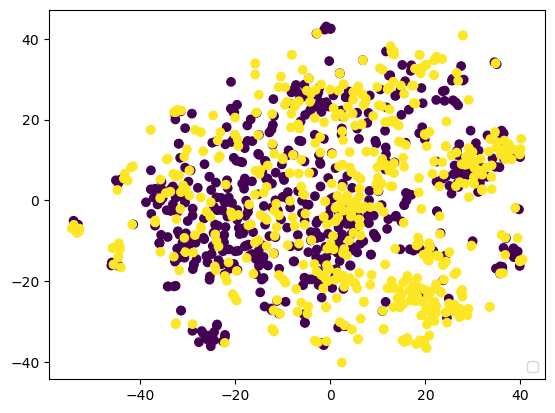

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9953703703703703
Training MCC Score: 0.9907424395461057
Training F1 Score: 0.9953703664012058
Training AUC VALUE: 0.9998336762688614
Training kappa Score: 0.9907407407407407
Training Precision: 0.9944547134935305
Training Recall: 0.9962962962962963
Training Sensitivity: 0.9962962962962963
Training Specificity: 0.9944444444444445
Training CCR: 0.9953703703703703
Training PPV: 0.9944547134935305


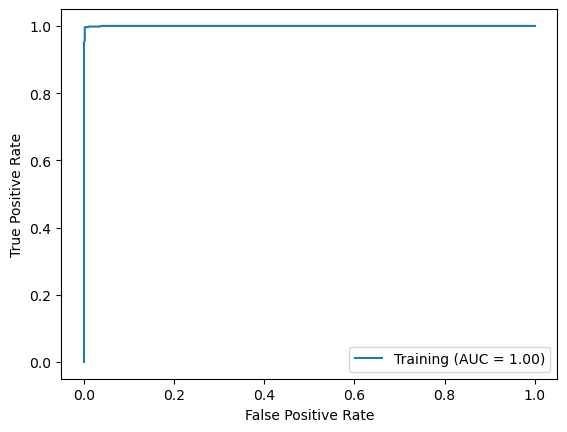

Testing Accuracy: 0.6696035242290749
Testing MCC Score: 0.31894928277511736
Testing F1 Score: 0.6370322993284296
Testing AUC VALUE: 0.7286427145708583
Testing kappa Score: 0.2968653202824928
Testing Precision: 0.859375
Testing Recall: 0.6586826347305389
Testing Sensitivity: 0.6586826347305389
Testing Specificity: 0.7
Testing CCR: 0.6696035242290749
Testing PPV: 0.859375


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


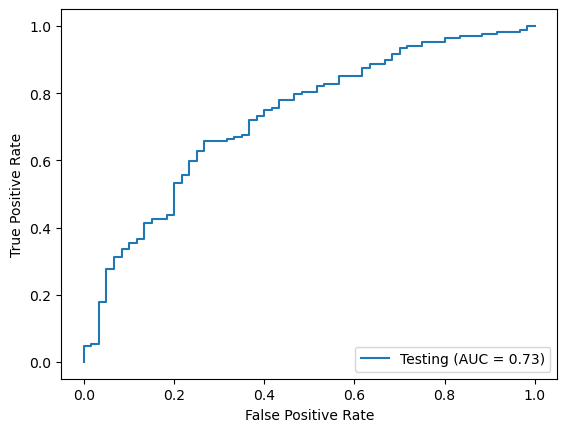

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #2


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


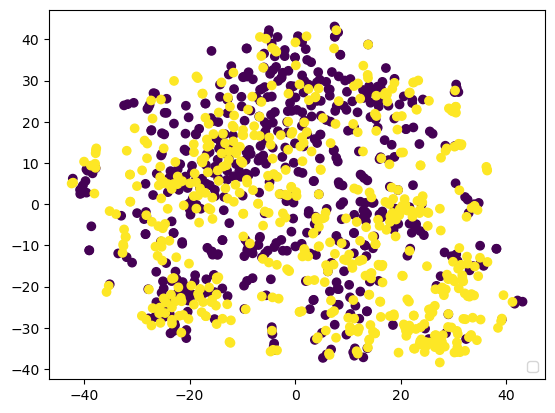

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9962962962962963
Training MCC Score: 0.9925994005679326
Training F1 Score: 0.9962962835949369
Training AUC VALUE: 0.9999571330589849
Training kappa Score: 0.9925925925925926
Training Precision: 0.9981412639405205
Training Recall: 0.9944444444444445
Training Sensitivity: 0.9944444444444445
Training Specificity: 0.9981481481481481
Training CCR: 0.9962962962962963
Training PPV: 0.9981412639405205


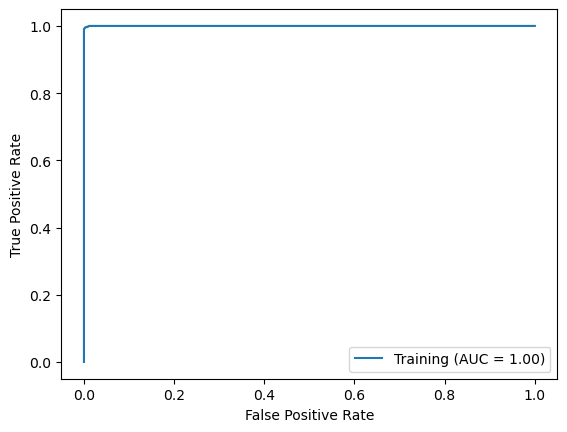

Testing Accuracy: 0.6211453744493393
Testing MCC Score: 0.23080027587366972
Testing F1 Score: 0.589529015979815
Testing AUC VALUE: 0.7042914171656687
Testing kappa Score: 0.2111685792791338
Testing Precision: 0.8292682926829268
Testing Recall: 0.6107784431137725
Testing Sensitivity: 0.6107784431137725
Testing Specificity: 0.65
Testing CCR: 0.6211453744493393
Testing PPV: 0.8292682926829268


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


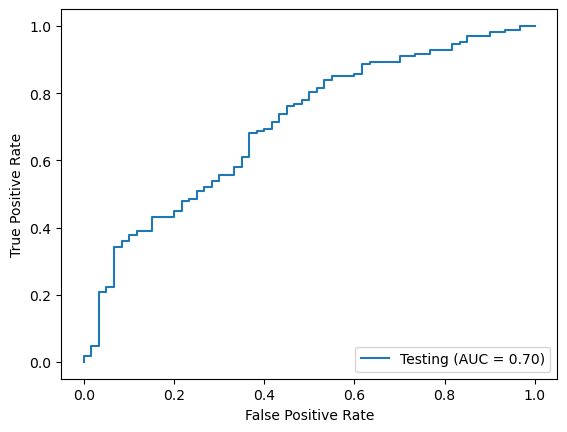

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #3


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


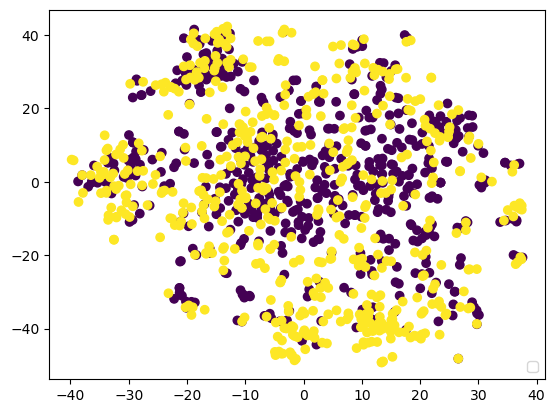

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9962962962962963
Training MCC Score: 0.9925925925925926
Training F1 Score: 0.9962962962962963
Training AUC VALUE: 0.9999845679012346
Training kappa Score: 0.9925925925925926
Training Precision: 0.9962962962962963
Training Recall: 0.9962962962962963
Training Sensitivity: 0.9962962962962963
Training Specificity: 0.9962962962962963
Training CCR: 0.9962962962962963
Training PPV: 0.9962962962962963


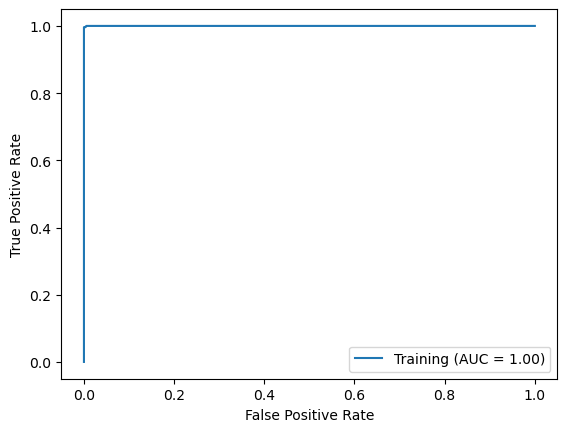

Testing Accuracy: 0.6211453744493393
Testing MCC Score: 0.2865673107499711
Testing F1 Score: 0.6010055591890124
Testing AUC VALUE: 0.7202594810379241
Testing kappa Score: 0.25007682851874613
Testing Precision: 0.8648648648648649
Testing Recall: 0.5748502994011976
Testing Sensitivity: 0.5748502994011976
Testing Specificity: 0.75
Testing CCR: 0.6211453744493393
Testing PPV: 0.8648648648648649


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


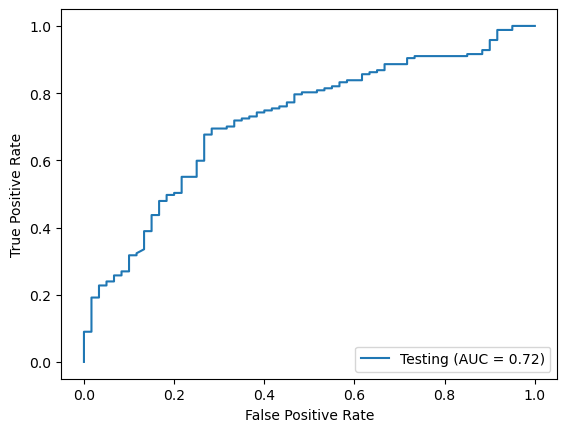

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #4


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


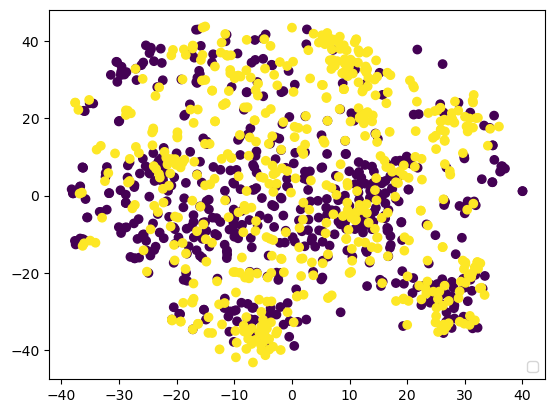

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9972222222222222
Training MCC Score: 0.9944597911645768
Training F1 Score: 0.9972222007885863
Training AUC VALUE: 0.9998611111111111
Training kappa Score: 0.9944444444444445
Training Precision: 0.994475138121547
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 0.9944444444444445
Training CCR: 0.9972222222222222
Training PPV: 0.994475138121547


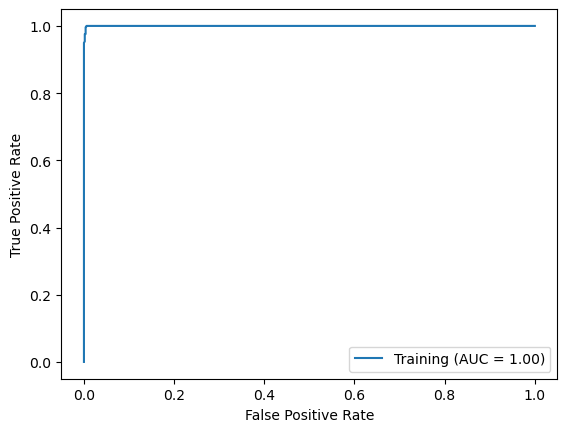

Testing Accuracy: 0.6563876651982379
Testing MCC Score: 0.28432053296631865
Testing F1 Score: 0.6214078002052685
Testing AUC VALUE: 0.7241516966067865
Testing kappa Score: 0.2654940678669211
Testing Precision: 0.8449612403100775
Testing Recall: 0.6526946107784432
Testing Sensitivity: 0.6526946107784432
Testing Specificity: 0.6666666666666666
Testing CCR: 0.6563876651982379
Testing PPV: 0.8449612403100775


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


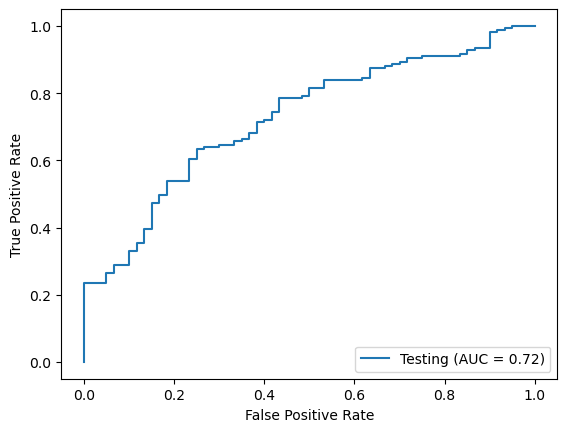

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #5


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


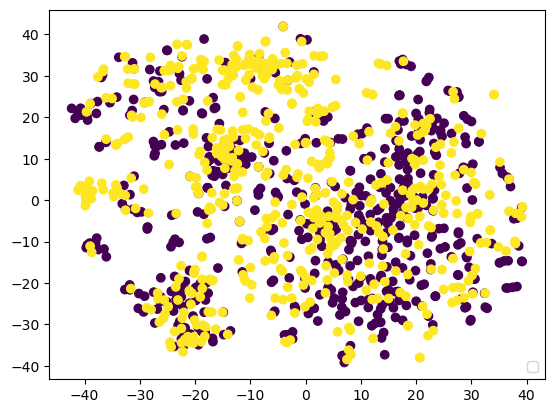

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9944444444444445
Training MCC Score: 0.9888956714613358
Training F1 Score: 0.9944444253924054
Training AUC VALUE: 0.9999022633744856
Training kappa Score: 0.9888888888888889
Training Precision: 0.992619926199262
Training Recall: 0.9962962962962963
Training Sensitivity: 0.9962962962962963
Training Specificity: 0.9925925925925926
Training CCR: 0.9944444444444445
Training PPV: 0.992619926199262


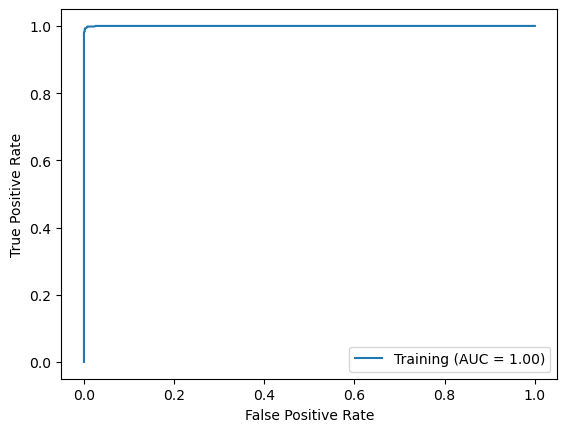

Testing Accuracy: 0.6475770925110133
Testing MCC Score: 0.2819636412214217
Testing F1 Score: 0.6161001183832234
Testing AUC VALUE: 0.7020958083832334
Testing kappa Score: 0.25980272275209915
Testing Precision: 0.848
Testing Recall: 0.6347305389221557
Testing Sensitivity: 0.6347305389221557
Testing Specificity: 0.6833333333333333
Testing CCR: 0.6475770925110133
Testing PPV: 0.848


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


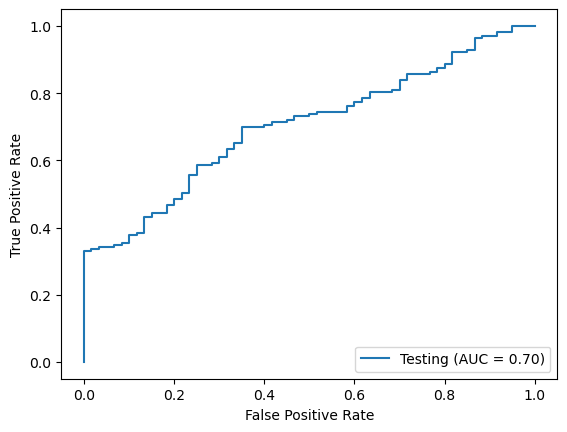

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #6


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


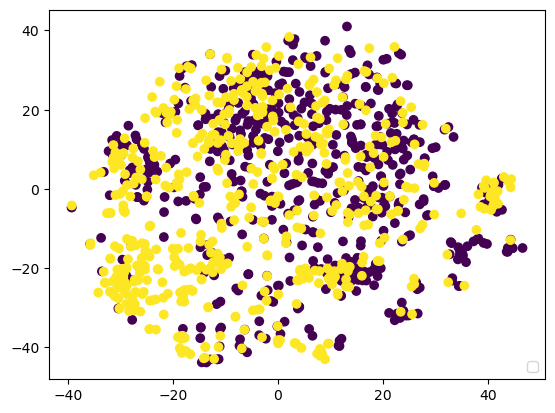

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9972222222222222
Training MCC Score: 0.9944461496004837
Training F1 Score: 0.9972222198407235
Training AUC VALUE: 0.9999811385459534
Training kappa Score: 0.9944444444444445
Training Precision: 0.9981447124304267
Training Recall: 0.9962962962962963
Training Sensitivity: 0.9962962962962963
Training Specificity: 0.9981481481481481
Training CCR: 0.9972222222222222
Training PPV: 0.9981447124304267


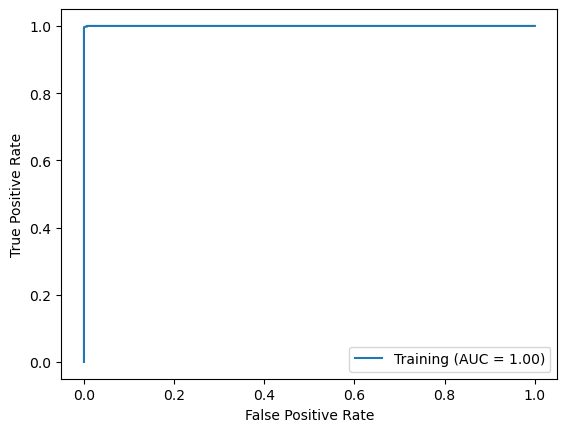

Testing Accuracy: 0.6299559471365639
Testing MCC Score: 0.26912237917632625
Testing F1 Score: 0.6031468531468531
Testing AUC VALUE: 0.7318363273453095
Testing kappa Score: 0.2426120114394661
Testing Precision: 0.8487394957983193
Testing Recall: 0.6047904191616766
Testing Sensitivity: 0.6047904191616766
Testing Specificity: 0.7
Testing CCR: 0.6299559471365639
Testing PPV: 0.8487394957983193


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


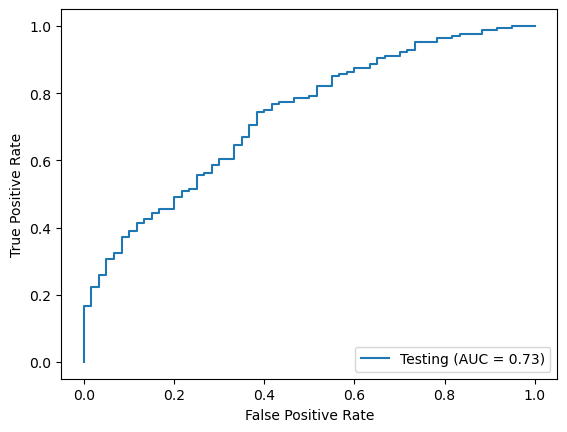

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #7


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


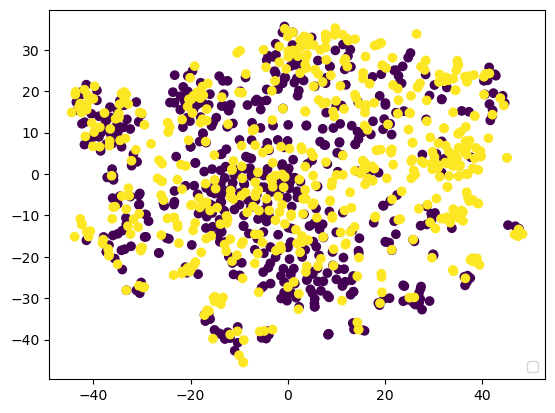

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9981481481481481
Training MCC Score: 0.9962962962962963
Training F1 Score: 0.9981481481481481
Training AUC VALUE: 0.9999777091906722
Training kappa Score: 0.9962962962962963
Training Precision: 0.9981481481481481
Training Recall: 0.9981481481481481
Training Sensitivity: 0.9981481481481481
Training Specificity: 0.9981481481481481
Training CCR: 0.9981481481481481
Training PPV: 0.9981481481481481


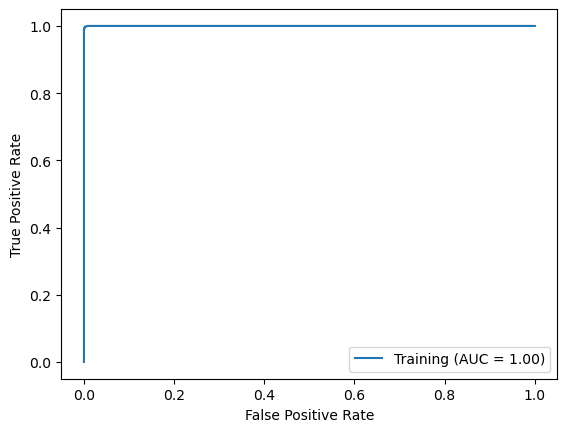

Testing Accuracy: 0.6475770925110133
Testing MCC Score: 0.27303290837189925
Testing F1 Score: 0.6139455782312926
Testing AUC VALUE: 0.7066866267465071
Testing kappa Score: 0.2532894736842106
Testing Precision: 0.84251968503937
Testing Recall: 0.6407185628742516
Testing Sensitivity: 0.6407185628742516
Testing Specificity: 0.6666666666666666
Testing CCR: 0.6475770925110133
Testing PPV: 0.84251968503937


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


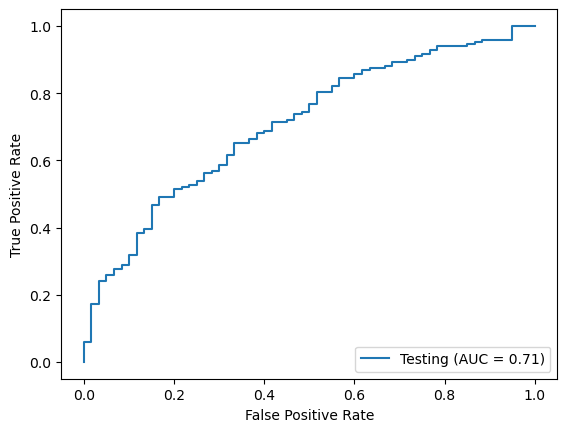

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #8


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


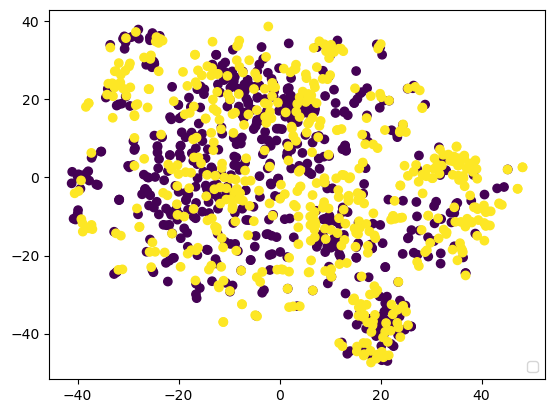

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9962962962962963
Training MCC Score: 0.9925925925925926
Training F1 Score: 0.9962962962962963
Training AUC VALUE: 0.999948559670782
Training kappa Score: 0.9925925925925926
Training Precision: 0.9962962962962963
Training Recall: 0.9962962962962963
Training Sensitivity: 0.9962962962962963
Training Specificity: 0.9962962962962963
Training CCR: 0.9962962962962963
Training PPV: 0.9962962962962963


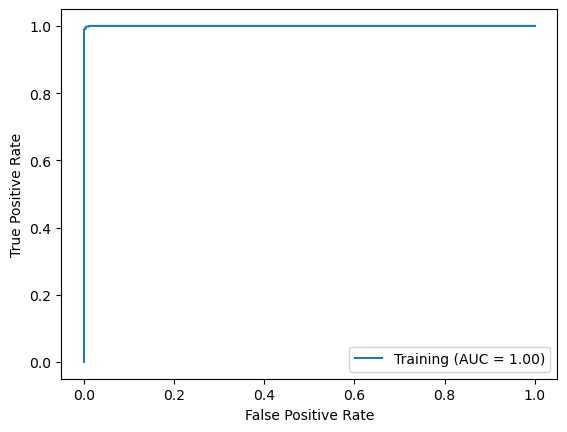

Testing Accuracy: 0.5903083700440529
Testing MCC Score: 0.13764338830946216
Testing F1 Score: 0.549920051167253
Testing AUC VALUE: 0.6424151696606787
Testing kappa Score: 0.128112997150291
Testing Precision: 0.7890625
Testing Recall: 0.6047904191616766
Testing Sensitivity: 0.6047904191616766
Testing Specificity: 0.55
Testing CCR: 0.5903083700440529
Testing PPV: 0.7890625


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


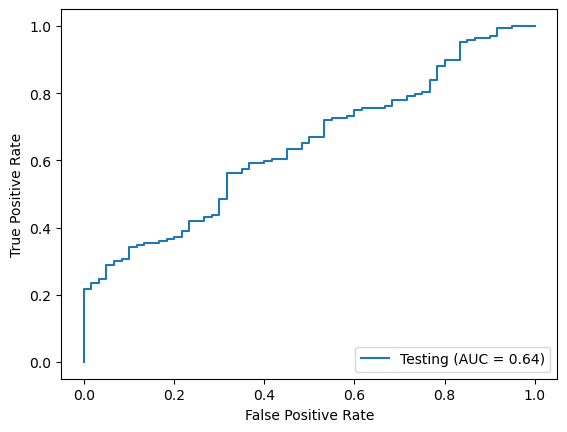

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #9


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


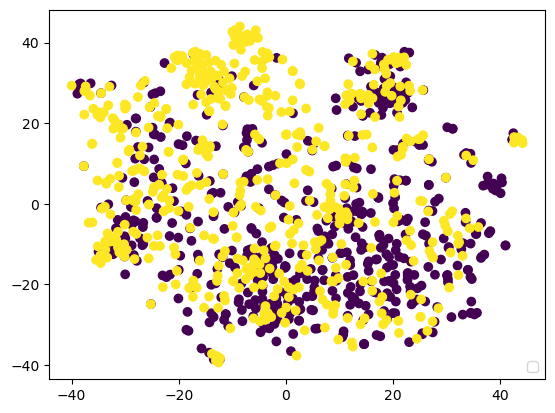

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9962962962962963
Training MCC Score: 0.9925994005679326
Training F1 Score: 0.9962962835949369
Training AUC VALUE: 0.9999279835390947
Training kappa Score: 0.9925925925925926
Training Precision: 0.9944649446494465
Training Recall: 0.9981481481481481
Training Sensitivity: 0.9981481481481481
Training Specificity: 0.9944444444444445
Training CCR: 0.9962962962962963
Training PPV: 0.9944649446494465


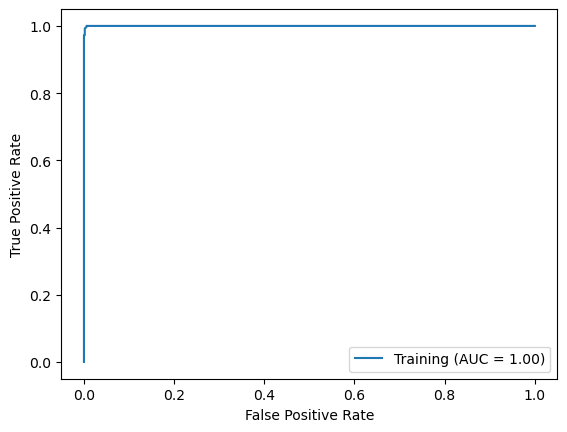

Testing Accuracy: 0.5594713656387665
Testing MCC Score: 0.06246166708603813
Testing F1 Score: 0.5146253848785494
Testing AUC VALUE: 0.5912175648702594
Testing kappa Score: 0.05832572803451419
Testing Precision: 0.7596899224806202
Testing Recall: 0.5868263473053892
Testing Sensitivity: 0.5868263473053892
Testing Specificity: 0.48333333333333334
Testing CCR: 0.5594713656387665
Testing PPV: 0.7596899224806202


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


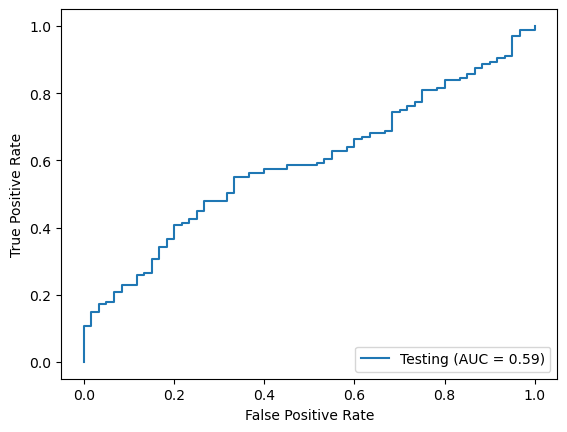

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Fold #10


C:\Users\DELL\AppData\Local\Temp\ipykernel_72276\387347609.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


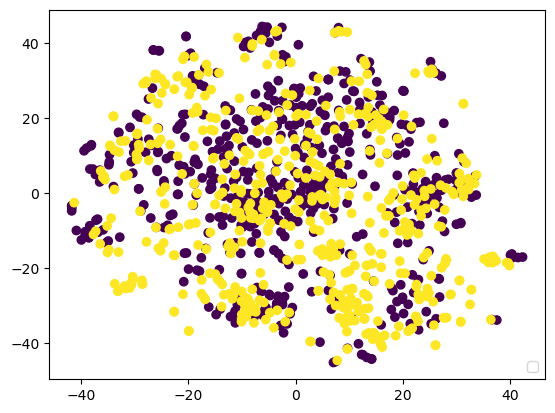

0  
0.0    540
1.0    540
Name: count, dtype: int64
Training Accuracy: 0.9981481481481481
Training MCC Score: 0.9962962962962963
Training F1 Score: 0.9981481481481481
Training AUC VALUE: 0.9999845679012346
Training kappa Score: 0.9962962962962963
Training Precision: 0.9981481481481481
Training Recall: 0.9981481481481481
Training Sensitivity: 0.9981481481481481
Training Specificity: 0.9981481481481481
Training CCR: 0.9981481481481481
Training PPV: 0.9981481481481481


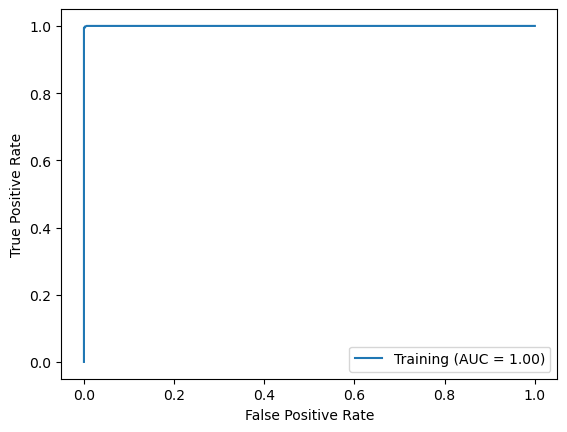

Testing Accuracy: 0.6592920353982301
Testing MCC Score: 0.306056717850358
Testing F1 Score: 0.6285671597191096
Testing AUC VALUE: 0.7602409638554216
Testing kappa Score: 0.2828649138712602
Testing Precision: 0.856
Testing Recall: 0.6445783132530121
Testing Sensitivity: 0.6445783132530121
Testing Specificity: 0.7
Testing CCR: 0.6592920353982301
Testing PPV: 0.856


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


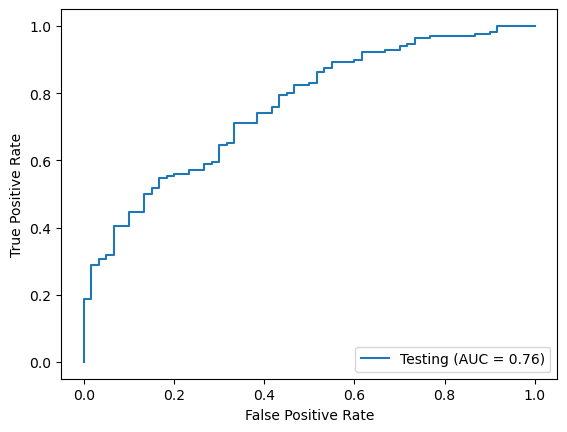

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob)\n    all_labels.extend(Final_Ytrain)\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob)\n    all_labels.extend(Test_y)\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [41]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# 用于存储训练和测试集的预测结果和标签

total_metrics = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

Parameters = pd.DataFrame.from_dict(Best_params).iloc[8].to_dict()
print(Parameters)
# 10 折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    # 获取训练集和测试集
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y))
    print(Final_Ytrain.value_counts())
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # 使用 KNeighborsClassifier
    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])

    
    # 拟合模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 训练集预测
    y_train_pred = rf.predict(Final_Xtrain)
    y_train_prob = rf.predict_proba(Final_Xtrain)[:, 1]
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred, y_train_prob, Final_Ytrain, 'Training'))

    # 测试集预测
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob)
    all_labels.extend(Final_Ytrain)
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob)
    all_labels.extend(Test_y)

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

In [43]:
#Analyse the training metrics sorted by descending Training Accuracy
pd.DataFrame.from_dict(Test_Fold_outs_1).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.669604,0.318949,0.637032,0.728643,0.296865,0.859375,0.658683,0.658683,0.700000,0.669604,0.859375
9,0.659292,0.306057,0.628567,0.760241,0.282865,0.856000,0.644578,0.644578,0.700000,0.659292,0.856000
3,0.656388,0.284321,0.621408,0.724152,0.265494,0.844961,0.652695,0.652695,0.666667,0.656388,0.844961
4,0.647577,0.281964,0.616100,0.702096,0.259803,0.848000,0.634731,0.634731,0.683333,0.647577,0.848000
6,0.647577,0.273033,0.613946,0.706687,0.253289,0.842520,0.640719,0.640719,0.666667,0.647577,0.842520
2,0.621145,0.286567,0.601006,0.720259,0.250077,0.864865,0.574850,0.574850,0.750000,0.621145,0.864865
5,0.629956,0.269122,0.603147,0.731836,0.242612,0.848739,0.604790,0.604790,0.700000,0.629956,0.848739
1,0.621145,0.230800,0.589529,0.704291,0.211169,0.829268,0.610778,0.610778,0.650000,0.621145,0.829268
7,0.590308,0.137643,0.549920,0.642415,0.128113,0.789062,0.604790,0.604790,0.550000,0.590308,0.789062
8,0.559471,0.062462,0.514625,0.591218,0.058326,0.759690,0.586826,0.586826,0.483333,0.559471,0.759690


<Axes: >

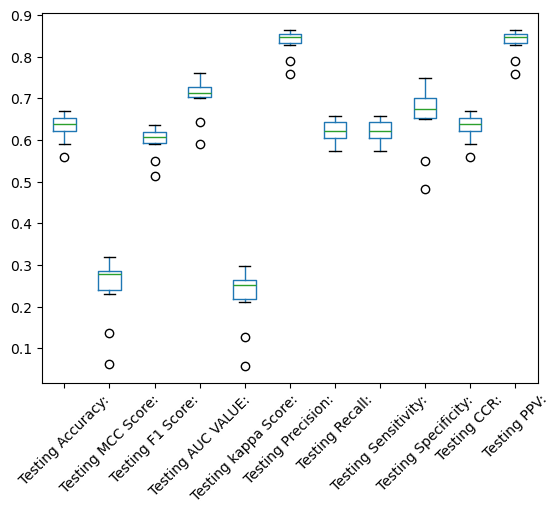

In [44]:
#To visualize the stability of the tuned model with each fold
(pd.DataFrame(Test_Fold_outs_1)).boxplot(grid=False,rot=45)

In [45]:
pd.DataFrame(Test_Fold_outs_1)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.669604,0.318949,0.637032,0.728643,0.296865,0.859375,0.658683,0.658683,0.700000,0.669604,0.859375
1,0.621145,0.230800,0.589529,0.704291,0.211169,0.829268,0.610778,0.610778,0.650000,0.621145,0.829268
2,0.621145,0.286567,0.601006,0.720259,0.250077,0.864865,0.574850,0.574850,0.750000,0.621145,0.864865
3,0.656388,0.284321,0.621408,0.724152,0.265494,0.844961,0.652695,0.652695,0.666667,0.656388,0.844961
4,0.647577,0.281964,0.616100,0.702096,0.259803,0.848000,0.634731,0.634731,0.683333,0.647577,0.848000
5,0.629956,0.269122,0.603147,0.731836,0.242612,0.848739,0.604790,0.604790,0.700000,0.629956,0.848739
6,0.647577,0.273033,0.613946,0.706687,0.253289,0.842520,0.640719,0.640719,0.666667,0.647577,0.842520
7,0.590308,0.137643,0.549920,0.642415,0.128113,0.789062,0.604790,0.604790,0.550000,0.590308,0.789062
8,0.559471,0.062462,0.514625,0.591218,0.058326,0.759690,0.586826,0.586826,0.483333,0.559471,0.759690
9,0.659292,0.306057,0.628567,0.760241,0.282865,0.856000,0.644578,0.644578,0.700000,0.659292,0.856000


In [46]:
TRAIN = Data.drop(['smiles','status'],axis=1)
TRAIN

,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,A1_9,...,E5_118,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127
0,0.094016,-0.055136,0.093916,0.094049,0.094048,0.094023,-0.094049,-0.093270,0.093939,0.094045,...,-0.112084,-0.007912,-0.008366,-0.116818,-0.006744,0.023309,-0.086551,0.110998,-0.016755,0.126777
1,-0.105073,-0.104954,0.077949,-0.098966,0.051879,0.102551,-0.077809,0.094111,0.098754,0.072003,...,-0.080569,-0.108469,-0.066381,0.049937,-0.007060,-0.099508,-0.064876,-0.117822,0.017419,0.065876
2,-0.093852,0.104293,0.104566,-0.105432,0.100401,-0.100579,-0.042242,0.105463,0.087505,-0.099997,...,-0.050873,0.003295,0.079961,0.068431,0.072388,0.031704,-0.156894,-0.076025,0.043912,0.091646
3,-0.099614,0.087038,0.060907,-0.098148,-0.045818,0.092176,0.090120,0.086224,-0.043515,0.050553,...,-0.112240,-0.058454,-0.023720,0.095611,-0.074631,-0.109076,0.044256,-0.090629,-0.113879,-0.077791
4,-0.091825,0.092849,0.092849,-0.092848,0.092849,-0.080430,0.092843,0.092849,-0.043309,0.091656,...,-0.071735,0.105175,0.081506,0.056766,0.095901,0.101593,-0.104216,-0.058318,0.077261,-0.096527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2264,0.080092,0.102274,-0.009088,-0.057085,-0.101187,0.098601,0.106478,-0.105857,-0.106245,0.031955,...,0.007841,0.083240,-0.123522,0.145380,0.077607,-0.065158,-0.054499,0.016188,0.026602,0.055832
2265,-0.104570,0.107860,0.071371,-0.107122,0.084389,0.097258,0.099946,-0.107713,-0.028845,-0.105003,...,0.051014,-0.003408,0.045207,0.032738,0.038317,0.114978,0.135628,-0.058013,0.165188,0.000684
2266,0.034437,0.083233,-0.097841,-0.074154,-0.099665,0.100696,0.101261,-0.100458,-0.100485,-0.060304,...,0.057814,-0.003826,0.053155,0.184424,0.136455,-0.098094,-0.129598,-0.074668,0.090778,0.003947
2267,-0.095955,0.076007,0.092876,0.094680,0.094566,0.096064,0.095005,-0.096065,-0.092807,0.089249,...,0.063077,0.043008,-0.037532,0.102230,0.111853,-0.071334,-0.127195,0.113832,-0.002970,0.071206


In [47]:
TRAIN = TRAIN[f_list] #Use features of the selected (hyperparameter tuned) model here
TRAIN

,A4_93,B2_38,B3_66,B5_15,B5_91,C1_79,C1_103,C2_43,C2_64,C3_64,...,E3_111,E4_5,E4_6,E4_64,E4_70,E4_111,E5_3,E5_54,E5_64,E5_115
0,-0.100560,0.107486,-0.118495,-0.077574,0.009253,-0.120195,-0.108578,0.017834,-0.088788,0.006008,...,0.096983,-0.021604,0.071950,-0.069127,-0.115040,0.114403,-0.072493,-0.128025,0.090164,-0.128234
1,-0.101457,-0.039138,0.036026,0.064380,0.098295,0.004380,0.021458,0.061342,0.073360,0.137297,...,0.138356,-0.107368,0.121204,-0.029831,0.065378,0.057636,0.103887,0.057979,-0.062228,-0.026171
2,-0.082221,-0.118128,0.087054,0.095115,-0.102188,0.012134,-0.102470,0.079005,0.067230,0.044549,...,-0.114265,-0.111538,0.112508,0.112271,-0.081160,-0.096047,0.020192,0.068417,0.079366,-0.093717
3,-0.096644,0.028566,-0.062984,-0.086432,0.103391,-0.011026,-0.118729,0.033085,-0.013959,0.095828,...,0.120817,-0.034815,0.109863,0.110862,-0.106029,-0.108380,0.101567,-0.088786,-0.075299,-0.107480
4,0.094539,0.016678,-0.103213,0.106917,0.005258,-0.035157,0.097573,-0.094136,0.116238,0.107678,...,0.004533,0.022708,-0.098687,-0.100377,-0.099338,-0.099749,-0.064677,0.062976,-0.097842,0.092611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2264,-0.090410,0.094091,-0.130081,0.010706,0.012156,0.093419,-0.093318,-0.078948,0.021070,0.091365,...,-0.108896,0.012678,0.020231,-0.017690,0.128310,0.091766,-0.105899,0.151778,-0.132761,0.123653
2265,0.077855,0.037430,0.008740,-0.040154,0.114792,0.100728,0.104291,0.010523,-0.086934,0.170593,...,-0.024907,0.066926,-0.119989,0.118180,-0.090496,0.116881,0.124665,0.019492,0.109932,-0.065556
2266,-0.092524,0.021208,-0.105718,0.003976,0.086565,-0.116132,-0.110496,-0.026060,-0.135220,0.084394,...,-0.125774,-0.122728,0.113012,0.067709,-0.099152,-0.120787,-0.107055,0.150852,-0.099069,0.043504
2267,-0.092799,0.044689,-0.087033,-0.002709,0.058067,0.092397,-0.076615,0.035379,-0.117748,0.118846,...,-0.038498,0.082394,-0.101827,-0.110025,0.001171,0.060427,-0.096323,0.100271,-0.061947,-0.081718


In [48]:
Y = Data['status']

In [49]:
#Fitting the model on whole data
fitted = models_1[0].fit(TRAIN,Y)
fitted

RandomForestClassifier(bootstrap=False, max_depth=110.0, max_features='sqrt',
                       min_samples_leaf=5, min_samples_split=13,
                       n_estimators=89)

In [50]:
#Save the final model
joblib.dump(fitted, 'AID_1259408_RF.pkl')

['AID_1259408_RF.pkl']

In [51]:
import joblib
import pandas as pd

class model_AID_1259408:
    def __init__(self, test):        
        self.test = test

    def extract_feature(self, data):        
        # 读取特征文件
        F_names = pd.read_csv('AID_1259408_features.csv')
        features = F_names.iloc[:, 0].tolist()
        return data[features]

    def get_labels(self, pred_test):
        # 根据概率预测类别
        test_pred = []
        for i in range(pred_test.shape[0]):
            if pred_test[i][0] > pred_test[i][1]:  # 类别 0 概率更大
                test_pred.append(0)
            else:
                test_pred.append(1)  # 类别 1 概率更大
        return test_pred

    def test_model(self):
        # 提取特征并加载本地的 KNN 模型进行预测
        test = self.test
        test_filtered = self.extract_feature(test.drop(['smiles'], axis=1))
        
        # 本地加载 KNN 模型
        model = joblib.load('AID_1259408_RF.pkl')
        
        # 使用模型进行预测
        probs = model.predict_proba(test_filtered)
        
        # 获取预测类别
        preds = self.get_labels(probs)
        
        return probs, preds


def AID_1259408(smi_list):
    Feature_data = pd.DataFrame()
    Feature_data['smiles'] = smi_list

    Sig_Carcin = Feature_Signaturizer(smi_list)
    
    # 保留删除前的索引
    original_index = Sig_Carcin.index
    
    # 删除缺失值的行
    Sig_Carcin_clean = Sig_Carcin.dropna()

    # 使用清理过的数据进行模型测试
    m4 = model_AID_1259408(Sig_Carcin_clean)  # 假设这里的模型函数改为 model_apoptosis
    probs, preds = m4.test_model()

    # 创建一个与原始索引匹配的结果数组
    Feature_data['AID_1259408_0'] = None
    Feature_data['AID_1259408_1'] = None
    Feature_data['AID_1259408_preds'] = None

    # 填充有效的预测结果
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259408_0'] = probs[:, 0]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259408_1'] = probs[:, 1]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259408_preds'] = preds

    return Feature_data


In [19]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'MKETn_Training_Data.csv') ### features in columns,molecules in rows
data

,SMILES,Name,CID,InChI,IUPAC,Status,Source
0,[As],Arsenic,5359596.0,1S/As,arsenic,1,CCRIS
1,[Be],Beryllium,5460467.0,1S/Be,beryllium,1,CCRIS
2,[Be]=O,Beryllium oxide,14775.0,1S/Be.O,oxoberyllium,1,CCRIS
3,[Be+2].[OH-].[OH-],Dihydroxyberyllium,25879.0,1S/Be.2H2O/h;2*1H2/q+2;;/p-2,beryllium;dihydroxide,1,CCRIS
4,[C-]#[Si+],Silicon carbide,9863.0,1S/CSi/c1-2,methanidylidynesilanylium,1,CCRIS
...,...,...,...,...,...,...,...
461,P#[Ga],Gallium phosphide,82901.0,1S/Ga.P,gallanylidynephosphane,0,CCRIS
462,S=[Cd],Cadmium sulfide,14783.0,1S/Cd.S,sulfanylidenecadmium,1,CCRIS
463,S=[Ni],Nickel sulfide,28094.0,1S/Ni.S,sulfanylidenenickel,1,CCRIS
464,S=P(N1CC1)(N1CC1)N1CCOCC1,Morzid,62432.0,"1S/C8H16N3OPS/c14-13(9-1-2-9,10-3-4-10)11-5-7-...",bis(aziridin-1-yl)-morpholin-4-yl-sulfanyliden...,1,CCRIS
